# Adaptive Visual Token Pruning Engine for Low-Token Document OCR

This notebook implements an end-to-end framework for dynamic visual token pruning and bipartite token merging (**ToMe**) for Document OCR (**Donut**).

### Kaggle Setup Instructions:
1. **GPU Accelerator:** Select `GPU T4 x2` or `GPU P100` under Notebook Options on the right sidebar.
2. **Internet:** Toggle `Internet` to **On** on the right sidebar.
3. Click **Run All** to train and benchmark the model.

In [1]:
# Cell 1: Environment Installation
!pip install -q "transformers>=4.38.0" "datasets>=2.16.0" "accelerate>=0.27.0" sentencepiece editdistance matplotlib pillow torchvision

In [2]:
# Cell 2: Imports, GPU Verification & Memory Optimization
import os
import gc
import time
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
from datasets import load_dataset
from transformers import VisionEncoderDecoderModel, DonutProcessor
from transformers.modeling_outputs import BaseModelOutput
from typing import Tuple, Optional, Sequence

# Enable expandable memory segments to avoid CUDA memory fragmentation
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

# Clean stale memory allocations
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# A CPU session is always a mistake here, and it does not announce itself: the
# 2026-08-29 attempt printed "Using device: cpu" and kept going. Training would
# numerics differ enough to trip the ablation's 0.5pt CONTROL check against
# run 5's GPU-produced reference. Fail immediately instead.
ALLOW_CPU = False  # set True only for a deliberate no-GPU smoke test
assert ALLOW_CPU or device.type == 'cuda', (
    'No GPU: Kaggle sidebar -> Session options -> Accelerator -> GPU T4 x2, '
    'then Run All. (Set ALLOW_CPU=True to override, expect hours not minutes.)')

if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    free_mem, total_mem = torch.cuda.mem_get_info()
    print(f'Available VRAM: {free_mem / (1024**3):.2f} GB / {total_mem / (1024**3):.2f} GB')

# ---- Phase 2c: eval-only resume (set this to skip the ~4h retrain) ----
# Point RESUME_CKPT at run 5's uploaded checkpoint to go straight to eval + the
# decoding ablation; leave it None to train normally. Validated HERE, before the
# ~19-minute dataset download in Cell 6, so a wrong path costs a minute.
RESUME_CKPT = '/kaggle/input/datasets/nafis8766/token-pruning-dataset/adaptive_donut_funsd.pt'  # e.g. '/kaggle/input/adaptive-donut-run5/adaptive_donut_funsd.pt'

if RESUME_CKPT and not os.path.exists(RESUME_CKPT):
    # The path is wrong in one of three ordinary ways: the dataset was uploaded
    # with its checkpoints/ folder (file sits one level deeper), the slug differs
    # from the dataset title, or the dataset was never attached. Resolve by
    # searching for the basename instead of guessing the shape.
    _want = os.path.basename(RESUME_CKPT)
    _found = [os.path.join(r, f)
              for r, _d, fs in os.walk('/kaggle/input') for f in fs if f == _want]
    if len(_found) == 1:
        print(f'RESUME_CKPT not at {RESUME_CKPT}\n  -> resolved to {_found[0]}')
        RESUME_CKPT = _found[0]
    else:
        _all_pt = [os.path.join(r, f)
                   for r, _d, fs in os.walk('/kaggle/input') for f in fs if f.endswith('.pt')]
        raise AssertionError(
            f'RESUME_CKPT not found: {RESUME_CKPT}\n'
            f'  matches for {_want!r}: {_found or "none"}\n'
            f'  .pt files mounted under /kaggle/input: {_all_pt or "NONE -- dataset not attached?"}\n'
            f'  top level of /kaggle/input: {sorted(os.listdir("/kaggle/input")) if os.path.isdir("/kaggle/input") else "MISSING"}\n'
            '  Fix: Add Input -> your dataset, then copy the path it shows.')

EVAL_ONLY = bool(RESUME_CKPT)
if EVAL_ONLY:
    print(f'EVAL-ONLY mode: will load {RESUME_CKPT}')
    print('  -> training skipped, and Cell 6 will skip building the train set')

# ---- Pending 1a: train the router WITH pruning ON (set False to reproduce the
# Phase 2d selection ablation on run-5 weights instead of retraining) ----
# Runs 2-5 trained at keep_ratio=1.0, so the STE multiplier was exactly 1.0 and the
# router never got gradient about REMOVING a token -- Diagnostic D1 showed it then
# ranks blank paper above text. Training at keep_ratio<1 makes K<N, so the kept
# set actually changes and the router finally learns which tokens matter.
DO_TRAIN = False                  # True: retrain-with-pruning-ON then sweep; False: sweep only
TRAIN_KEEP_RATIO = 0.50          # budget the router is trained to honor (Pending 1a)
TRAIN_EPOCHS = 5
PRUNED_CKPT = os.path.join('/kaggle/working' if os.path.isdir('/kaggle/working') else '.',
                           'adaptive_donut_pruned.pt')
# Sign-fix (Run 7 follow-up): supervise the router with a FREE text proxy (patch-ink
# contrast) via BCE so it learns to rank TEXT high, instead of the blank-paper-above-text
# inversion seen after STE-only training. When True, the ablation's forward `router`
# rows should jump from broken (~18 recall) to competitive -- that is the test.
SUPERVISE_SALIENCY = True
SALIENCY_THRESHOLD = 0.15     # keep patches whose within-patch std exceeds 15% of the image max

# ---- Pending 13(b): supervise the router with the DECODER'S OWN cross-attention
# instead of patch ink. Off by default, so SUPERVISE_SALIENCY alone still reproduces
# run 9 exactly and this stays a one-variable experiment.
#
# Why a different target at all: D6 showed that fitting the INK proxy harder cost
# accuracy at two of three budgets, so ink is not merely imperfect, it is the wrong
# thing to fit. D7 then showed what ink was actually supplying -- not correctness but
# three structural properties the task loss cannot supply (dense / coherent / free),
# because the STE reaches exactly K of N tokens and hands the other N-K exactly zero
# gradient. So the fix is to keep the SHAPE of the ink term and change its CONTENT.
# D8: attention is a genuinely different target (r(attn, ink) = +0.083) and not a fixed
# positional mask. D9: it is reachable by this very scorer (held-out AUC 0.976 vs a
# 0.498 shuffled floor, and +0.212 over a constant map). Best single motivator:
# r(attn, router score) = -0.045 -- the router is not just anti-correlated with ink, it
# is UNINFORMED about where the decoder looks.
#
# NOTHING above establishes that this WORKS. Every D8/D9 number is scored against the
# teacher's own attention and is close to tautological. The acceptance criterion is
# recall at keep=0.50 and 0.35 against run 9 -- NOT retained attention mass. Promoting
# a proxy to an acceptance gate is the mistake D2's withdrawn gate already made once.
ATTN_TARGET = False

# Both pairings are asserted HERE as well as in cell 11, for the reason stated above
# RESUME_CKPT: cell 2 runs before Cell 6's ~19-minute dataset download and cell 11 does
# not, so a config mistake caught here costs a minute instead of twenty. The most likely
# run-10 mistake is exactly this one -- flip ATTN_TARGET, forget to attach the run-5
# dataset -- and note that RESUME_CKPT's auto-resolution above only fires when it is
# already truthy, so leaving it None gets no help from it.
assert not ATTN_TARGET or (RESUME_CKPT and os.path.exists(RESUME_CKPT)), (
    f'ATTN_TARGET=True needs RESUME_CKPT pointing at run 5: the teacher has to be the '
    f'checkpoint D8/D9/D10 characterised, not donut-base\'s untuned decoder. Attach the '
    f'run-5 dataset and set RESUME_CKPT (currently {RESUME_CKPT!r}).')
assert not ATTN_TARGET or SUPERVISE_SALIENCY, (
    'ATTN_TARGET replaces the CONTENT of the saliency term, so the term has to be on. '
    'With SUPERVISE_SALIENCY=False, LAMBDA_SAL is 0 and this would be a silent no-op -- '
    'an all-STE run mislabelled as 13(b).')

EVAL_CKPT = RESUME_CKPT          # set by the training cell; used for clarity/logging
# One line that states every knob that shapes the run, because D5 is the standing case in
# this project of a knob (lambda_entropy=0.05) that shaped two runs while appearing nowhere
# in the log. ATTN_TARGET is the whole variable of run 10, so it goes here rather than only
# in cell 11's teacher-snapshot line.
# (The keep_ratio branch below was missing its `f` prefix through run 9, so the log read
# literally `keep_ratio={TRAIN_KEEP_RATIO}`. Harmless to the run, but it is the one line a
# reader checks the configuration against before an hour of training.)
print(f'PLAN: DO_TRAIN={DO_TRAIN} -> '
      + (f'retrain router WITH pruning ON (keep_ratio={TRAIN_KEEP_RATIO}), then sweep'
         if DO_TRAIN else 'sweep only on RESUME_CKPT'))
print(f'CFG: SUPERVISE_SALIENCY={SUPERVISE_SALIENCY} ATTN_TARGET={ATTN_TARGET} '
      + ('(target = FROZEN run-5 decoder cross-attention top-K -- Pending 13(b))'
         if ATTN_TARGET else f'(target = patch ink > {SALIENCY_THRESHOLD:g} -- run 9 config)')
      + f' | TRAIN_EPOCHS={TRAIN_EPOCHS} RESUME_CKPT={"set" if RESUME_CKPT else "None"}')


Using device: cuda
GPU: Tesla T4


Available VRAM: 14.46 GB / 14.56 GB
EVAL-ONLY mode: will load /kaggle/input/datasets/nafis8766/token-pruning-dataset/adaptive_donut_funsd.pt
  -> training skipped, and Cell 6 will skip building the train set
PLAN: DO_TRAIN=False -> sweep only on RESUME_CKPT
CFG: SUPERVISE_SALIENCY=True ATTN_TARGET=False (target = patch ink > 0.15 -- run 9 config) | TRAIN_EPOCHS=5 RESUME_CKPT=set


## 1. Core Architecture Modules
- **`PatchSaliencyRouter`:** Predicts patch importance scores and applies a Straight-Through Estimator (STE) top-k filter.
- **`BipartiteTokenMerger`:** Fully vectorized, non-in-place soft token merging via matrix operations.

In [3]:
# Cell 3: Patch Saliency Router and Vectorized ToMe Modules
class PatchSaliencyRouter(nn.Module):
    def __init__(self, hidden_dim: int = 1024, reduction_dim: int = 256):
        super().__init__()
        self.scorer = nn.Sequential(
            nn.Linear(hidden_dim, reduction_dim),
            nn.LayerNorm(reduction_dim),
            nn.GELU(),
            nn.Linear(reduction_dim, 1),
            nn.Sigmoid()
        )
        nn.init.constant_(self.scorer[-2].bias, 0.5)

    def forward(self, tokens, keep_ratio=0.35, coords=None, use_ste=True,
                select_scores=None, invert=False):
        """select_scores: (B, N) ranking signal used INSTEAD of the learned scores
        (uniform noise for a random control, patch ink for an oracle, a stratified
        key for a per-row budget). The learned `scores` are still computed and
        returned, so reporting is unaffected. invert: take the LOWEST-ranked
        tokens. Both are eval-only; see AGENTS.md Diagnostic D1/D2."""
        B, N, D = tokens.shape
        K = max(1, int(round(N * keep_ratio)))
        scores = self.scorer(tokens)  # (B, N, 1)
        
        if select_scores is not None:
            if select_scores.shape[:2] != (B, N):
                raise ValueError(
                    f'select_scores must be (B, N) = {(B, N)}, got {tuple(select_scores.shape)}')
            rank_by = select_scores.reshape(B, N).to(scores.dtype)
        else:
            rank_by = scores.squeeze(-1)
        topk_scores, topk_indices = torch.topk(rank_by, k=K, dim=1, largest=not invert, sorted=True)
        indices_expanded = topk_indices.unsqueeze(-1).expand(-1, -1, D)
        selected_tokens = torch.gather(tokens, dim=1, index=indices_expanded)
        
        # STE is skipped under an external ranking: topk_scores would then hold the
        # override's values, not the scorer's, so scaling tokens by them sends the
        # router head a gradient it is not responsible for.
        if self.training and use_ste and select_scores is None:
            ste_weights = topk_scores.unsqueeze(-1)
            ste_multiplier = 1.0 + (ste_weights - ste_weights.detach())
            selected_tokens = selected_tokens * ste_multiplier
            
        pruned_coords = None
        if coords is not None:
            coords_expanded = topk_indices.unsqueeze(-1).expand(-1, -1, coords.shape[-1])
            pruned_coords = torch.gather(coords, dim=1, index=coords_expanded)
            
        return selected_tokens, scores, topk_indices, pruned_coords


def checkerboard_color(orig_idx: torch.Tensor, grid_w: int) -> torch.Tensor:
    """Map ORIGINAL raster token indices to a {0, 1} checkerboard colour.

    Args:
        orig_idx: (B, K) positions into the encoder's pre-prune raster sequence
            (i.e. the router's `topk_indices`), NOT positions in the pruned
            sequence.
        grid_w: width of the token grid, so row = idx // grid_w, col = idx % grid_w.

    Returns:
        (B, K) tensor of 0/1. Colour is `(row + col) % 2`, which places every
        4-neighbour (up / down / left / right) in the OPPOSITE set.

    Why the original position and not the sequence position: the router's
    `torch.topk(..., sorted=True)` reorders the surviving tokens by descending
    score, so by the time they reach ToMe a token's index in the sequence means
    "rank", not "place on the page". The previous split (`arange(0,K,2)` /
    `arange(1,K,2)`) read that sequence position directly and therefore
    partitioned by score-rank parity. Deriving colour from `orig_idx` makes the
    split independent of the order tokens arrive in -- measured, see
    `scripts/diagnose_tome_parity.py`.

    Note this is also why raster order alone was not a fix: the grid is 60 wide
    and 60 is even, so `i` and `i + 60` (the token directly below) share parity
    and 100% of vertically-adjacent redundancy was unmergable. See AGENTS.md
    Gotchas.
    """
    if grid_w <= 0:
        raise ValueError(f"grid_w must be positive, got {grid_w}")
    if not torch.is_tensor(orig_idx):
        raise TypeError(f"orig_idx must be a tensor, got {type(orig_idx).__name__}")
    return ((orig_idx // grid_w) + (orig_idx % grid_w)) % 2


class BipartiteTokenMerger(nn.Module):
    """
    Bipartite Token Merging (ToMe) module for visual embeddings.

    Partitions the surviving visual tokens into two disjoint sets by CHECKERBOARD
    COLOUR OF THEIR ORIGINAL PAGE POSITION, computes cosine similarity across the
    two sets, and soft-merges the most mutually similar pairs -- compacting
    redundant regions without in-place mutation or autograd version conflicts.

    The split is order-independent by construction, which is the whole point: the
    router hands tokens over in descending-score order, so any split that reads
    sequence position strands roughly half of all genuinely-redundant pairs in
    the same set, where ToMe's A->B merge can never reach them.
    """
    def __init__(self, hidden_dim: int = 1024):
        super().__init__()
        self.hidden_dim = hidden_dim

    def forward(
        self,
        tokens: torch.Tensor,
        merge_ratio: float = 0.20,
        coords: Optional[torch.Tensor] = None,
        orig_idx: Optional[torch.Tensor] = None,
        token_grid: Optional[Sequence[int]] = None,
    ) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        """
        Merges redundant visual tokens via bipartite matching.

        Args:
            tokens (torch.Tensor): Visual token embeddings (B, K, D).
            merge_ratio (float): Fraction of tokens to merge away (0.0 <= merge_ratio < 0.5).
            coords (torch.Tensor, optional): 2D normalized coordinates (B, K, 2).
            orig_idx (torch.Tensor): (B, K) indices of these tokens in the
                encoder's ORIGINAL raster sequence -- the router's `topk_indices`.
                REQUIRED whenever merging actually happens; see the raise below.
            token_grid (tuple): (grid_h, grid_w) of the encoder token grid, e.g.
                (80, 60). Only `grid_w` is used. REQUIRED alongside `orig_idx`.

        Returns:
            merged_tokens (torch.Tensor): Compact token embeddings (B, M, D) where M = K - r.
            merged_coords (torch.Tensor, optional): Updated 2D centroid coordinates (B, M, 2).

        Raises:
            ValueError: if merging would happen but `orig_idx`/`token_grid` were
                not supplied. This is deliberate rather than a silent fallback to
                the old parity split: that split is only correct under raster
                order, the router does not deliver raster order, and the failure
                is invisible in the output (it produces a plausible merged tensor
                that merged the wrong things). A caller that has not thought
                about page position must not get a merge.
        """
        B, K, D = tokens.shape
        if K <= 4 or merge_ratio <= 0.0:
            return tokens, coords

        r = min(int(round(K * merge_ratio)), K // 2)
        if r <= 0:
            return tokens, coords

        if orig_idx is None or token_grid is None:
            raise ValueError(
                "BipartiteTokenMerger needs orig_idx (B, K) and token_grid "
                "(grid_h, grid_w) once merge_ratio > 0: the A/B split is a "
                "checkerboard over ORIGINAL page position, because the router "
                "delivers tokens in descending-score order and a split that "
                "reads sequence position merges by score-rank neighbourhood "
                "instead of spatial adjacency. See AGENTS.md Gotchas."
            )

        if len(token_grid) != 2:
            raise ValueError(f"token_grid must be (grid_h, grid_w), got {tuple(token_grid)}")
        grid_w = int(token_grid[1])
        if tuple(orig_idx.shape) != (B, K):
            raise ValueError(
                f"orig_idx must be (B, K) = {(B, K)}, got {tuple(orig_idx.shape)}"
            )

        color = checkerboard_color(orig_idx, grid_w)  # (B, K) in {0, 1}

        # Membership is per-image (it depends on which tokens the router kept), so
        # K_A varies down the batch even though K does not. Loop rather than pad:
        # B is small, the existing code already loops for the unmerged gather, and
        # M = K_B + (K_A - r) = K - r is constant regardless of how the split
        # falls -- which is what keeps the output batchable.
        idx_A_list = [torch.nonzero(color[b] == 0, as_tuple=False).squeeze(-1) for b in range(B)]
        idx_B_list = [torch.nonzero(color[b] == 1, as_tuple=False).squeeze(-1) for b in range(B)]

        min_K_A = min(int(x.numel()) for x in idx_A_list)
        min_K_B = min(int(x.numel()) for x in idx_B_list)
        if min_K_A == 0 or min_K_B == 0:
            # A degenerate selection (every kept token one colour) has nothing to
            # merge into. Pass through rather than merge the wrong things.
            return tokens, coords

        # r must be uniform across the batch or M would differ per image.
        r_actual = min(r, min_K_A)
        if r_actual <= 0:
            return tokens, coords

        out_tokens_list = []
        out_coords_list = []
        for b in range(B):
            idx_A, idx_B = idx_A_list[b], idx_B_list[b]
            A = tokens[b:b + 1, idx_A, :]          # (1, K_A, D)
            B_set = tokens[b:b + 1, idx_B, :]      # (1, K_B, D)
            coords_A = coords[b:b + 1, idx_A, :] if coords is not None else None
            coords_B = coords[b:b + 1, idx_B, :] if coords is not None else None

            K_A, K_B = A.shape[1], B_set.shape[1]

            A_norm = F.normalize(A, p=2, dim=-1)
            B_norm = F.normalize(B_set, p=2, dim=-1)
            sim = torch.bmm(A_norm, B_norm.transpose(1, 2))  # (1, K_A, K_B)

            max_sim_val, max_sim_idx = sim.max(dim=-1)       # (1, K_A)
            _, top_r_A_idx = torch.topk(max_sim_val, k=r_actual, dim=-1, largest=True)

            T = torch.zeros((1, K_A, K_B), device=tokens.device, dtype=tokens.dtype)
            row_idx = torch.zeros((1, r_actual), dtype=torch.long, device=tokens.device)
            target_b = torch.gather(max_sim_idx, 1, top_r_A_idx)
            T[row_idx, top_r_A_idx, target_b] = 1.0

            T_t = T.transpose(1, 2)                          # (1, K_B, K_A)
            W_B = 1.0 + T_t.sum(dim=-1, keepdim=True)        # (1, K_B, 1)
            B_merged = (B_set + torch.bmm(T_t, A)) / W_B

            mask_A = torch.ones((1, K_A), dtype=torch.bool, device=tokens.device)
            mask_A[row_idx, top_r_A_idx] = False
            A_unmerged = A[0, mask_A[0]].unsqueeze(0)        # (1, K_A - r, D)

            out_tokens_list.append(torch.cat([B_merged, A_unmerged], dim=1))

            if coords is not None:
                coords_B_merged = (coords_B + torch.bmm(T_t, coords_A)) / W_B
                coords_A_unmerged = coords_A[0, mask_A[0]].unsqueeze(0)
                out_coords_list.append(torch.cat([coords_B_merged, coords_A_unmerged], dim=1))

        out_tokens = torch.cat(out_tokens_list, dim=0)
        out_coords = torch.cat(out_coords_list, dim=0) if coords is not None else None

        return out_tokens, out_coords


In [4]:
# Cell 4: Custom Multi-Task Sparsity Loss
class AdaptivePruningLoss(nn.Module):
    def __init__(self, lambda_sparsity=2.0, lambda_entropy=0.05, target_budget=0.25, pad_token_id=-100):
        super().__init__()
        self.lambda_sparsity = lambda_sparsity
        self.lambda_entropy = lambda_entropy
        self.target_budget = target_budget
        self.ce_loss_fn = nn.CrossEntropyLoss(ignore_index=pad_token_id)

    def forward(self, decoder_logits, labels, scores, provided_ce_loss=None):
        if provided_ce_loss is not None:
            ce_loss = provided_ce_loss
        elif decoder_logits is not None and labels is not None:
            vocab_size = decoder_logits.shape[-1]
            ce_loss = self.ce_loss_fn(decoder_logits.view(-1, vocab_size), labels.view(-1))
        else:
            ce_loss = torch.tensor(0.0, device=scores.device)

        mean_score = scores.mean()
        target_tensor = torch.tensor(self.target_budget, device=scores.device, dtype=scores.dtype)
        sparsity_loss = F.smooth_l1_loss(mean_score, target_tensor)

        eps = 1e-7
        clamped_scores = scores.clamp(min=eps, max=1.0 - eps)
        entropy = -(clamped_scores * torch.log(clamped_scores) + (1.0 - clamped_scores) * torch.log(1.0 - clamped_scores)).mean()
        entropy_loss = -entropy

        total_loss = ce_loss + self.lambda_sparsity * sparsity_loss + self.lambda_entropy * entropy_loss
        return {
            'loss': total_loss,
            'ce_loss': ce_loss,
            'sparsity_loss': sparsity_loss,
            'mean_score': mean_score.detach()
        }

## 2. Integrated Model Architecture (`AdaptiveDonutOCR`)
Freezes the Swin vision encoder to eliminate 14 GB of attention graph storage, training the router and text decoder with under 2 GB VRAM.

In [5]:
# Cell 5: AdaptiveDonutOCR Model
SELECT_MODES = ('router', 'negated', 'random', 'ink', 'stratified', 'stratified_negated')
TOME_SPLITS = ('checkerboard', 'rank_parity')

TOKEN_GRID = (80, 60)   # Swin-B at 2560x1920, total stride 32 -> 80*60 = 4800 tokens


def patch_ink(pixel_values, num_tokens, stride=32):
    """Per-token within-patch contrast on the encoder's own token grid -> (B, N).

    A learning-free proxy for 'there is text here', used as the ink oracle's ranking
    signal and as the retained-ink diagnostic.

    Within-patch std rather than mean darkness because std is blind to whether Donut
    padded with black or white -- uniform padding has zero contrast either way, while
    darkness would score black padding as maximum ink. No un-normalization is needed:
    donut-base uses image_mean = image_std = 0.5 on every channel, so pixel_values is
    a uniform affine image of luminance and a plain channel mean ranks identically to
    true grayscale.
    """
    B, _, H, W = pixel_values.shape
    gh, gw = H // stride, W // stride
    if gh * gw != num_tokens:
        raise ValueError(
            f'token grid mismatch: pixel_values {H}x{W} at stride {stride} gives '
            f'{gh}x{gw}={gh * gw} patches but the encoder emitted {num_tokens} tokens')
    gray = pixel_values.mean(dim=1)                                    # (B, H, W)
    blocks = gray.unfold(1, stride, stride).unfold(2, stride, stride)   # (B,gh,gw,s,s)
    return blocks.reshape(B, gh * gw, -1).std(dim=-1)                  # (B, N)


def attn_topk_target(teacher_decoder, visual_tokens, decoder_input_ids, labels,
                     num_tokens, keep_ratio):
    """Dense binary target from a FROZEN teacher decoder's cross-attention -> (B, N).

    Pending 13(b). patch_ink is a proxy for "there is text here"; this is a proxy for
    "the decoder actually looks here". D8 measured those to be DIFFERENT targets
    (r(attn, ink) = +0.083, and attention is not a fixed positional mask: its top-5%
    centroid moves 6.12 grid rows across pages where ink's moves 1.81). D9 measured this
    target to be reachable by this very scorer (held-out AUC 0.976 against a 0.498
    shuffled floor, and +0.212 over the best page-INDEPENDENT constant map).

    Computed on the fly rather than cached, which is NOT the obvious choice -- the target
    is a function of (image, text) and both are fixed per example, so caching looks free.
    It is not: funsd_train is built with augment=True and repeated FUNSD_REPEAT times, so
    each page is drawn 8 times under a fresh random DOC_AUG (+-2 deg rotation, 0.9-1.05
    scale). This target is a POSITIONAL label on an 80x60 grid, so a cached one would sit
    1-4 grid cells off the content it labels -- the same order as the text lines being
    labelled -- while patch_ink, computed from the same augmented pixel_values, stays
    perfectly aligned. That asymmetry would bias the experiment AGAINST this target for a
    reason unrelated to its quality. See AGENTS.md Pending 13.

    Attends over the FULL num_tokens visual tokens, never the student's pruned K. That is
    the entire point of a dense target: D7 measured the STE handing exactly zero gradient
    to the N-K dropped tokens (2400 of 4800 at keep=0.50), so a target defined only on the
    kept set could not reach the half that needs teaching.
    """
    if visual_tokens.shape[1] != num_tokens:
        raise ValueError(
            f'teacher must attend over the FULL grid: got {visual_tokens.shape[1]} '
            f'visual tokens but the router scored {num_tokens}. Passing the PRUNED '
            f'tokens here would silently produce a target defined only on the kept set.')
    # Pads carry attention mass too, and decoder_input_ids is padded to 512 while a real
    # FUNSD target is ~310 tokens -- so ~40% of the text positions would contribute noise
    # to every token's score. Mask them, and truncate to the longest real prefix in the
    # batch, which also shrinks the (B, heads, T, N) attention tensor by the same ~40%.
    # (D8/D9 did not need this: they tokenized without padding.)
    mask = None
    ids = decoder_input_ids
    if labels is not None:
        mask = (labels != -100)
        t_real = max(1, int(mask.sum(dim=1).max().item()))
        ids, mask = ids[:, :t_real], mask[:, :t_real].to(visual_tokens.dtype)
    with torch.no_grad():
        out = teacher_decoder(input_ids=ids,
                             encoder_hidden_states=visual_tokens.detach(),
                             output_attentions=True, return_dict=True)
        ca = getattr(out, 'cross_attentions', None)
        # transformers 5.x defaults to SDPA, which does not materialise attention weights
        # and returns None here INSTEAD OF RAISING. The target would then be all-zero and
        # would train perfectly quietly, so this is checked every step rather than trusted.
        if not ca or ca[0] is None:
            raise RuntimeError(
                'teacher decoder returned no cross_attentions -- attention weights are '
                'not being materialised (SDPA/flash). The target would be silently '
                "all-zero. Fix: config._attn_implementation = 'eager' on the teacher.")
        # Mean over heads, sum over text positions, mean over layers. Mean over layers is
        # deliberate and is a LIVE UNTESTED KNOB: D8 found the deepest layer both the most
        # ink-aligned (r +0.201 vs +0.083 for the mean) and the most page-varying, so a
        # per-layer choice may well be better. The mean is used because it is the
        # aggregation whose properties D8 and D9 actually measured.
        acc = None
        for a in ca:
            w = a.mean(dim=1)                                    # (B, T, N)
            if mask is not None:
                w = w * mask[:, :w.shape[1], None]
            s = w.sum(dim=1)                                     # (B, N)
            acc = s if acc is None else acc + s
        attn = (acc / len(ca)).float()
    K = max(1, int(round(num_tokens * keep_ratio)))
    tgt = torch.zeros_like(attn)
    tgt.scatter_(1, attn.topk(K, dim=1).indices, 1.0)
    return tgt


def stratified_scores(scores, grid=TOKEN_GRID, negate=False):
    """Rewrite a ranking so a GLOBAL top-K becomes a PER-GRID-ROW top-k.

    Diagnostic D2: a single global top-k has no mechanism bounding worst-case
    coverage. It may spend the entire budget on one dense region, and the trained
    router does something like this -- its MINIMUM text-line ink coverage is 0.000,
    i.e. at least one line of the page loses all its ink, while total retained ink
    looks unremarkable. Recall is gated by the worst line, not the average.

    A per-row budget makes starving a line structurally impossible. Rather than add a
    second selection path to the router (a new path is a new place for the two to
    diverge), stratification is expressed purely as a monotone rewrite of the ranking
    signal, reusing the select_scores machinery unchanged:

        key = (gw - within_row_rank) + normalized_score

    within_row_rank is an integer in [0, gw), so the integer part dominates and the
    normalized score only breaks ties INSIDE a rank band; the bands cannot overlap
    because the score term is clamped strictly below 1.0. A global top-K with
    K = gh * k therefore selects exactly the top-k of every row. When K is not a
    multiple of gh it degrades gracefully -- whole bands fill first, the remainder
    goes to the best scores in the next band, and rows differ by at most 1.

    negate ranks by the negated score WITHIN each row, which is the fix for a
    sign-inverted scorer. Stratification and sign are orthogonal -- hence two modes.
    """
    B, N = scores.shape
    gh, gw = grid
    if gh * gw != N:
        raise ValueError(
            f'token grid mismatch: grid {gh}x{gw}={gh * gw} but got {N} tokens')
    s = (-scores if negate else scores).reshape(B, gh, gw)
    order = s.argsort(dim=-1, descending=True)
    rank = torch.empty_like(order)
    rank.scatter_(-1, order, torch.arange(gw, device=s.device).expand_as(order))
    lo = s.amin(dim=(1, 2), keepdim=True)
    hi = s.amax(dim=(1, 2), keepdim=True)
    s_norm = ((s - lo) / (hi - lo).clamp(min=1e-9)).clamp(0.0, 0.999)
    return ((gw - rank).to(s.dtype) + s_norm).reshape(B, N)


class AdaptiveDonutOCR(nn.Module):
    def __init__(self, base_model_name='naver-clova-ix/donut-base', keep_ratio=0.35, merge_ratio=0.0, freeze_encoder=True):
        super().__init__()
        self.base_model_name = base_model_name
        self.keep_ratio = keep_ratio
        self.merge_ratio = merge_ratio
        
        # Clean cache
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            
        print(f'Loading base backbone {base_model_name}...')
        self.model = VisionEncoderDecoderModel.from_pretrained(
            base_model_name,
            low_cpu_mem_usage=True
        )
        
        # Freeze vision encoder to eliminate the 14 GB Swin attention memory graph
        if freeze_encoder:
            print('Vision backbone frozen (saves ~12 GB VRAM). Training Router & Decoder!')
            for param in self.model.encoder.parameters():
                param.requires_grad = False
                
        hidden_dim = self.model.config.encoder.hidden_size
        self.router = PatchSaliencyRouter(hidden_dim=hidden_dim)
        self.tome_merger = BipartiteTokenMerger(hidden_dim=hidden_dim)

    def _generate_2d_coords(self, B, N, device, dtype=torch.float32):
        aspect_ratio = 4.0 / 3.0
        W_grid = int(round((N * aspect_ratio) ** 0.5))
        H_grid = max(1, N // W_grid)
        grid_y, grid_x = torch.meshgrid(
            torch.linspace(0, 1, H_grid, device=device, dtype=dtype),
            torch.linspace(0, 1, W_grid, device=device, dtype=dtype),
            indexing='ij'
        )
        coords_2d = torch.stack([grid_x, grid_y], dim=-1).view(-1, 2)
        if coords_2d.shape[0] < N:
            pad = coords_2d[-1:].repeat(N - coords_2d.shape[0], 1)
            coords_2d = torch.cat([coords_2d, pad], dim=0)
        else:
            coords_2d = coords_2d[:N]
        return coords_2d.unsqueeze(0).expand(B, -1, -1)

    def _token_grid(self, pixel_values: torch.Tensor, num_tokens: int, stride: int = 32) -> Tuple[int, int]:
        """(gh, gw) of the encoder token grid, derived from the input, not assumed.

        ToMe's checkerboard split needs the grid WIDTH to turn a raster index into
        (row, col). A wrong width is the worst kind of bug here because it is
        silent: any width still yields a valid two-colour partition, just one that
        no longer corresponds to spatial adjacency, and the output tensor looks
        exactly as it should. So derive from pixel_values like `patch_ink` does and
        let a mismatch raise, rather than trusting the TOKEN_GRID constant.
        """
        H, W = pixel_values.shape[-2], pixel_values.shape[-1]
        gh, gw = H // stride, W // stride
        if gh * gw != num_tokens:
            raise ValueError(
                f"token grid mismatch: pixel_values {H}x{W} at stride {stride} gives "
                f"{gh}x{gw}={gh * gw} patches but the encoder emitted {num_tokens} "
                f"tokens (TOKEN_GRID constant is {TOKEN_GRID})"
            )
        return (gh, gw)

    def _tome_partition(self, pixel_values, num_tokens, topk_indices, merge_ratio,
                        tome_split='checkerboard'):
        """(orig_idx, token_grid) for ToMe's A/B split, or (None, None) when off.

        checkerboard -- the shipped behaviour. Colour comes from each token's
            ORIGINAL raster position (`topk_indices`), so the split does not depend
            on the descending-score order the router delivers tokens in.
        rank_parity -- the NEGATIVE CONTROL, and the only reason this argument
            exists. grid_w=1 makes ((i // 1) + (i % 1)) % 2 == i % 2, so a sequential
            orig_idx reproduces the pre-2026-09-14 `arange(0, K, 2)` /
            `arange(1, K, 2)` split EXACTLY -- bit for bit, with no change to the
            merger and no fallback path inside it. The checkerboard fix has so far
            only been shown to move a synthetic missed-redundancy percentage
            (49.2%/50.5% -> 0.0%/0.0%, scripts/diagnose_tome_parity.py); nobody has
            shown it moves RECALL. This arm is what lets a real number say so.

        Resolved only when merging is actually on, so a non-standard input still
        runs fine at merge_ratio=0.
        """
        if merge_ratio <= 0.0:
            return None, None
        if tome_split == 'checkerboard':
            return topk_indices, self._token_grid(pixel_values, num_tokens)
        if tome_split == 'rank_parity':
            B_, K_ = topk_indices.shape
            seq = torch.arange(K_, device=topk_indices.device).unsqueeze(0).expand(B_, K_)
            return seq, (K_, 1)
        raise ValueError(
            f"tome_split must be 'checkerboard' or 'rank_parity', got {tome_split!r}")

    def forward(self, pixel_values, labels=None, decoder_input_ids=None, keep_ratio=None, merge_ratio=None):
        k_ratio = keep_ratio if keep_ratio is not None else self.keep_ratio
        m_ratio = merge_ratio if merge_ratio is not None else self.merge_ratio
        B = pixel_values.shape[0]
        device = pixel_values.device
        
        # Forward pass through encoder (under no_grad when frozen to save 12GB)
        encoder_is_frozen = not any(p.requires_grad for p in self.model.encoder.parameters())
        if encoder_is_frozen:
            with torch.no_grad():
                encoder_outputs = self.model.encoder(pixel_values)
        else:
            encoder_outputs = self.model.encoder(pixel_values)
            
        visual_tokens = encoder_outputs.last_hidden_state
        N = visual_tokens.shape[1]
        
        coords = self._generate_2d_coords(B, N, device, dtype=visual_tokens.dtype)
        selected_tokens, scores, topk_indices, pruned_coords = self.router(
            visual_tokens, keep_ratio=k_ratio, coords=coords, use_ste=self.training
        )
        
        # `topk_indices` is not optional. The router returns tokens sorted by
        # DESCENDING SCORE, so a token's position in `selected_tokens` says nothing
        # about where it sits on the page; ToMe splits A/B by the checkerboard
        # colour of the ORIGINAL raster position, which is what topk_indices carries.
        tome_orig_idx, tome_grid = self._tome_partition(
            pixel_values, N, topk_indices, m_ratio)
        compressed_tokens, _ = self.tome_merger(
            selected_tokens, merge_ratio=m_ratio, coords=pruned_coords,
            orig_idx=tome_orig_idx, token_grid=tome_grid
        )
        M = compressed_tokens.shape[1]
        
        # NOTE: self.model.decoder is an MBartForCausalLM, which does NOT shift
        # labels internally. Feeding decoder_input_ids == labels and letting the
        # decoder compute the loss trains the model to COPY the current token
        # (next-token loss == 0) and collapses generation to a repeated token.
        # Fix: get raw logits, then compute the loss with an explicit right-shift
        # so position t predicts token t+1 (standard autoregressive objective).
        decoder_outputs = self.model.decoder(
            input_ids=decoder_input_ids,
            encoder_hidden_states=compressed_tokens,
            return_dict=True
        )
        logits = decoder_outputs.logits
        
        loss = None
        if labels is not None:
            shift_logits = logits[:, :-1, :].contiguous()
            shift_labels = labels[:, 1:].contiguous()
            loss = F.cross_entropy(
                shift_logits.view(-1, shift_logits.size(-1)),
                shift_labels.view(-1),
                ignore_index=-100
            )
        
        return {
            'loss': loss,
            'logits': logits,
            'scores': scores,
            'visual_tokens': visual_tokens,
            'topk_indices': topk_indices,
            'original_tokens': N,
            'compressed_tokens': M,
            'compression_ratio': (1.0 - (M / N)) * 100.0
        }

    @torch.no_grad()
    def generate(self, pixel_values, decoder_input_ids=None, max_length=256,
                 keep_ratio=None, merge_ratio=None, select_mode='router',
                 tome_split='checkerboard', **kwargs):
        k_ratio = keep_ratio if keep_ratio is not None else self.keep_ratio
        m_ratio = merge_ratio if merge_ratio is not None else self.merge_ratio
        B = pixel_values.shape[0]
        device = pixel_values.device
        
        encoder_outputs = self.model.encoder(pixel_values)
        visual_tokens = encoder_outputs.last_hidden_state
        N = visual_tokens.shape[1]
        
        # select_mode swaps the RANKING SIGNAL only. K, the architecture and the
        # decoder are untouched, so every row costs the same and stays comparable.
        #   router  -- the learned scores (the actual model)
        #   negated -- the same scores, lowest-first. D1 found the trained router
        #              anti-correlated with ink, so this retains MORE text (0.62-0.66
        #              vs 0.34-0.38) -- yet loses to random, so ink is necessary and
        #              not sufficient.
        #   random  -- uniform noise: the floor the router must beat. Drawn fresh per
        #              image from the ambient RNG (one fixed mask is a positional
        #              prior, a different and easier target); seed in the eval loop.
        #   ink     -- patch contrast, no learning: an ORACLE bounding what any
        #              ink-seeking router could reach on this decoder.
        #   stratified / stratified_negated -- the SAME learned scores under a
        #              per-grid-row budget instead of one global top-k (D2). Tests
        #              whether the selection RULE is the bug rather than the scorer.
        if select_mode not in SELECT_MODES:
            raise ValueError(f'select_mode must be one of {SELECT_MODES}, got {select_mode!r}')
        # Validated HERE and not only inside _tome_partition, which returns early
        # when merge_ratio == 0: a typo'd split would otherwise pass silently on
        # every prune-only row and then surface as a merge row that looks like it
        # ran the arm its label names.
        if tome_split not in TOME_SPLITS:
            raise ValueError(f'tome_split must be one of {TOME_SPLITS}, got {tome_split!r}')
        select_scores = None
        invert = False
        if select_mode == 'negated':
            invert = True
        elif select_mode == 'random':
            select_scores = torch.rand(B, N, device=device, dtype=visual_tokens.dtype)
        elif select_mode == 'ink':
            select_scores = patch_ink(pixel_values, N).to(visual_tokens.dtype)
        elif select_mode in ('stratified', 'stratified_negated'):
            # Grid derived from pixel_values, not assumed, so a non-standard input
            # raises here instead of silently stratifying over the wrong axis.
            grid = (pixel_values.shape[-2] // 32, pixel_values.shape[-1] // 32)
            raw = self.router.scorer(visual_tokens).squeeze(-1)
            select_scores = stratified_scores(
                raw, grid=grid, negate=(select_mode == 'stratified_negated')
            ).to(visual_tokens.dtype)

        coords = self._generate_2d_coords(B, N, device, dtype=visual_tokens.dtype)
        selected_tokens, scores, topk_indices, pruned_coords = self.router(
            visual_tokens, keep_ratio=k_ratio, coords=coords, use_ste=False,
            select_scores=select_scores, invert=invert
        )
        
        tome_orig_idx, tome_grid = self._tome_partition(
            pixel_values, N, topk_indices, m_ratio, tome_split=tome_split)
        compressed_tokens, _ = self.tome_merger(
            selected_tokens, merge_ratio=m_ratio, coords=pruned_coords,
            orig_idx=tome_orig_idx, token_grid=tome_grid
        )
        M = compressed_tokens.shape[1]
        
        custom_encoder_output = BaseModelOutput(last_hidden_state=compressed_tokens)
        
        # Prime the decoder with the task prompt (<s_doc>) exactly as trained.
        # donut-base's config leaves decoder_start/eos/pad unset, so pass them
        # explicitly; otherwise generation cannot stop and runs to max_length.
        gen_kwargs = dict(kwargs)
        if decoder_input_ids is not None:
            gen_kwargs['decoder_input_ids'] = decoder_input_ids
        else:
            gen_kwargs.setdefault('decoder_start_token_id', self.model.config.decoder_start_token_id or 0)
        gen_kwargs.setdefault('eos_token_id', 2)
        gen_kwargs.setdefault('pad_token_id', 1)
        # Decoding defaults set by the Phase 2c ablation (50 FUNSD docs, run-5
        # weights, CONTROL row reproduced run 5 to 0.00 pt). See
        # results/ablation_decoding.json.
        #
        # repetition_penalty MUST stay 1.0. At the old 1.3 it capped output at
        # 71% of gold length and cost 27.2 pts of recall: HF penalizes every
        # token already emitted, but a full-page form legitimately re-uses its
        # whole vocabulary, so after ~80 words every plausible continuation is
        # downweighted while EOS -- never emitted -- is not. EOS wins and the
        # model stops mid-page. It also ate the repeated '"' in the JSON prefix
        # (valid JSON 0% -> 82% once removed).
        #
        # no_repeat_ngram_size stays 3. It was a no-op at rp=1.3 (nothing
        # repeated for it to block), but with rp=1.0 it is the guard against
        # greedy repetition collapse: dropping it over-generates to 124.6% of
        # gold, sends 22% of docs into max_length, and costs 6.7 pts of recall.
        gen_kwargs.setdefault('repetition_penalty', 1.0)
        gen_kwargs.setdefault('no_repeat_ngram_size', 3)
        
        generated_ids = self.model.generate(
            encoder_outputs=custom_encoder_output,
            max_length=max_length,
            **gen_kwargs
        )
        
        # Retained ink: what fraction of the page's contrast survived pruning.
        # Logged per call because it is the number that EXPLAINS an accuracy row --
        # without it a bad row reads as 'pruning hurts' rather than 'we pruned the
        # text'. Guarded: a non-standard grid must not invalidate the accuracy row.
        retained_ink = None
        try:
            ink = patch_ink(pixel_values, N)
            kept = ink.gather(1, topk_indices).sum(dim=1)
            retained_ink = float((kept / ink.sum(dim=1).clamp(min=1e-9)).mean())
        except ValueError:
            pass

        return generated_ids, {
            'original_tokens': N,
            'compressed_tokens': M,
            'compression_ratio': (1.0 - (M / N)) * 100.0,
            'select_mode': select_mode,
            'merge_ratio': m_ratio,
            'tome_split': tome_split if m_ratio > 0.0 else None,
            'retained_ink': retained_ink,
            'scores': scores,
            'topk_indices': topk_indices
        }

## 3. Dataset Loading & Preprocessing
Loads English document dataset (`nielsr/funsd`) and formats samples for Donut.

In [6]:
# Cell 6: Data Pipeline
from torchvision import transforms as T

MAX_WORDS = 128

# Phase 1.5: document-appropriate augmentation (TRAIN split only) to fight the
# 149-image overfit. Mild geometric + photometric jitter only -- NO flips or
# aggressive crops, which would destroy or drop text. fill=255 keeps the paper
# background white where rotation/scale expose the corners.
DOC_AUG = T.Compose([
    T.RandomApply([T.RandomRotation(degrees=2, fill=255)], p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.RandomApply([T.RandomAffine(degrees=0, scale=(0.9, 1.05), fill=255)], p=0.3),
    T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5))], p=0.3),
])


def reading_order_words(words, bboxes):
    """Sort words top-to-bottom, left-to-right using boxes [x0,y0,x1,y1].
    FUNSD stores words in form-annotation order, not reading order, so a naive
    join yields a scrambled target the decoder cannot learn or be scored on."""
    if not bboxes or len(bboxes) != len(words):
        return list(words)
    hs = sorted(b[3] - b[1] for b in bboxes if b[3] > b[1])
    tol = max(1.0, (hs[len(hs) // 2] * 0.6) if hs else 10.0)
    lines = []
    for i in sorted(range(len(words)), key=lambda k: bboxes[k][1]):
        top = bboxes[i][1]
        for anchor, idxs in lines:
            if abs(top - anchor) <= tol:
                idxs.append(i)
                break
        else:
            lines.append((top, [i]))
    out = []
    for _, idxs in lines:
        out.extend(sorted(idxs, key=lambda k: bboxes[k][0]))
    return [words[i] for i in out]


from torch.utils.data import ConcatDataset


def build_target_text(sample):
    '''Unified target across mixed sources -> the words for {"text": ...}, capped
    at MAX_WORDS. FUNSD: reading-ordered words. SynthDoG-en: gt_parse.text_sequence.
    Keeps the decoder on ONE output schema.'''
    words = sample.get('words')
    if words:
        boxes = sample.get('bboxes') or sample.get('boxes')
        if boxes:
            words = reading_order_words(words, boxes)
        return ' '.join(words[:MAX_WORDS])
    gt = sample.get('ground_truth')
    if gt:
        try:
            obj = json.loads(gt) if isinstance(gt, str) else gt
            parse = obj.get('gt_parse', obj) if isinstance(obj, dict) else {}
            seq = parse.get('text_sequence', '') if isinstance(parse, dict) else str(parse)
        except Exception:
            seq = gt if isinstance(gt, str) else ''
        return ' '.join(seq.split()[:MAX_WORDS])
    return 'sample document'


class DocumentDataset(Dataset):
    def __init__(self, dataset_name='nielsr/funsd', split='train', processor=None, max_samples=None, augment=False):
        self.processor = processor
        self.augment = augment
        raw = load_dataset(dataset_name, split=split)
        if max_samples and max_samples < len(raw):
            raw = raw.select(range(max_samples))
        self.dataset = raw

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]
        img = sample['image'].convert('RGB')
        if self.augment:
            img = DOC_AUG(img)
        pixel_values = self.processor(img, return_tensors='pt').pixel_values.squeeze(0)
        
        target_json = json.dumps({'text': build_target_text(sample)})
        prompt = f'<s_doc>{target_json}</s>'
        
        labels = self.processor.tokenizer(
            prompt, add_special_tokens=False, max_length=512, padding='max_length', truncation=True, return_tensors='pt'
        ).input_ids.squeeze(0)
        labels[labels == self.processor.tokenizer.pad_token_id] = -100
        
        decoder_input_ids = labels.clone()
        decoder_input_ids[decoder_input_ids == -100] = self.processor.tokenizer.pad_token_id
        return {
            'pixel_values': pixel_values,
            'labels': labels,
            'decoder_input_ids': decoder_input_ids,
            'raw_text': target_json
        }

def collate_fn(batch):
    return {
        'pixel_values': torch.stack([item['pixel_values'] for item in batch]),
        'labels': torch.stack([item['labels'] for item in batch]),
        'decoder_input_ids': torch.stack([item['decoder_input_ids'] for item in batch])
    }

processor = DonutProcessor.from_pretrained('naver-clova-ix/donut-base')

# Phase 2b: the SynthDoG-heavy mix (run 4: 63% synth, encoder frozen) REGRESSED
# recall -- clean synthetic text is off-domain for FUNSD's noisy scans, and a
# frozen encoder cannot adapt to it anyway. Now that the top Swin stage is
# unfrozen (see training cell) the encoder can learn FUNSD glyphs directly, so
# SynthDoG is demoted to a small anti-overfit garnish and FUNSD dominates (~70%).
SYNTH_N, FUNSD_REPEAT = 500, 8

# In eval-only mode none of this is used: the training loop never runs, and
# train_loader is referenced ONLY inside the epoch loop body. Building it anyway
# cost ~19 minutes of SynthDoG download on the 2026-08-29 attempt before the run
# failed on an unrelated path error, so skip it outright.
if EVAL_ONLY and not DO_TRAIN:
    train_ds = train_loader = funsd_train = synth_train = None
    print('EVAL-ONLY mode: skipped train set (no FUNSD-aug / SynthDoG download)')
else:
    funsd_train = DocumentDataset(dataset_name='nielsr/funsd', split='train', processor=processor, augment=True)
    synth_train = DocumentDataset(dataset_name='naver-clova-ix/synthdog-en', split=f'train[:{SYNTH_N}]', processor=processor, augment=False)
    train_ds = ConcatDataset([funsd_train] * FUNSD_REPEAT + [synth_train])
    print(f'Mixed train set: {len(funsd_train)} FUNSD x{FUNSD_REPEAT} + {len(synth_train)} SynthDoG = {len(train_ds)} samples')
    # batch_size = 1 with gradient accumulation = 8 ensures no OOM
    train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, collate_fn=collate_fn)
    print(f'Train samples: {len(train_ds)}')

test_ds = DocumentDataset(dataset_name='nielsr/funsd', split='test', processor=processor)
print(f'Test samples: {len(test_ds)}')

preprocessor_config.json:   0%|          | 0.00/362 [00:00<?, ?B/s]

The image processor of type `DonutImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/518 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

data/train-00000-of-00001.parquet:   0%|          | 0.00/12.3M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/4.38M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/149 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/50 [00:00<?, ? examples/s]

Test samples: 50


## 4. Training on Kaggle GPU
Trains the Saliency Router and fine-tunes token economy with mixed precision (`fp16`).

In [7]:
# Cell 7: Model Training
# ---------------------------------------------------------------------------
# Pending 1a: TRAIN THE ROUTER WITH PRUNING ON
# keep_ratio<1 => K<N => the STE multiplier (1 + score - score.detach()) is no
# longer exactly 1.0, so gradient finally reaches the router head about which
# tokens to KEEP. Sparsity loss now targets the real budget. Diagnostic D2 says
# do NOT reward summed retained saliency (that ranks negated above random); this
# loss only pulls mean(score) toward TRAIN_KEEP_RATIO, a soft budget without the
# inverted incentive. Worst-case line coverage is bounded separately by Pending
# 1d's stratified selection, not by this loss.
# ---------------------------------------------------------------------------
if DO_TRAIN:
    TRAIN_KEEP_RATIO = float(TRAIN_KEEP_RATIO)
    model = AdaptiveDonutOCR(keep_ratio=TRAIN_KEEP_RATIO, merge_ratio=0.0,
                              freeze_encoder=True).to(device)
    # Start from run-5 weights if supplied, then retrain the routing under pruning.
    if RESUME_CKPT and os.path.exists(RESUME_CKPT):
        _sd = torch.load(RESUME_CKPT, map_location=device, weights_only=True)
        _m, _u = model.load_state_dict(_sd, strict=False)
        print(f'Resumed {RESUME_CKPT} (missing={len(_m)}, unexpected={len(_u)}) '
              f'for pruning-ON retrain')
    # Pending 13(b): snapshot a FROZEN teacher decoder for the cross-attention target.
    # Built HERE, immediately after the run-5 load and BEFORE any training step, because
    # the teacher must be run 5 -- the ceiling model D8 and D9 measured. Once the loop
    # starts, model.model.decoder is the student and drifts away from it.
    #
    # Freezing is what makes this target COHERENT, which is the property D7 identified as
    # the one ink was really supplying. An online target that moved with the student would
    # reintroduce exactly the incoherence (cos 0.21 across pages) that made
    # CE-through-STE useless despite being 8-30x larger by gradient norm.
    _teacher_dec = None
    if ATTN_TARGET:
        import copy
        assert RESUME_CKPT and os.path.exists(RESUME_CKPT), (
            'ATTN_TARGET needs RESUME_CKPT: the teacher must be the run-5 checkpoint that '
            'D8/D9 characterised. Without it the "teacher" is donut-base\'s untuned '
            'decoder, which was never measured and is not the ceiling model.')
        assert SUPERVISE_SALIENCY, (
            'ATTN_TARGET replaces the CONTENT of the saliency term, so the term has to be '
            'on. With SUPERVISE_SALIENCY=False, LAMBDA_SAL is 0 and this would be a silent '
            'no-op -- an all-STE run mislabelled as 13(b).')
        _teacher_dec = copy.deepcopy(model.model.decoder).eval()
        for _p in _teacher_dec.parameters():
            _p.requires_grad = False
        # transformers 5.x defaults to SDPA, which does not materialise attention weights
        # and then returns cross_attentions=None rather than raising. Set eager here;
        # attn_topk_target asserts non-empty every step in case this did not take.
        for _cfg in (getattr(_teacher_dec, 'config', None),
                     getattr(getattr(_teacher_dec, 'model', None), 'config', None)):
            if _cfg is not None:
                _cfg._attn_implementation = 'eager'
                _cfg.output_attentions = True
        print('13(b): frozen teacher decoder snapshotted from run 5 (eager attention). '
              'Target = top-K of its cross-attention, NOT patch ink.')
    # Unfreeze top Swin stage (mirrors run 5) so features adapt to FUNSD glyphs.
    UNFREEZE_STAGES = 1
    _stages = model.model.encoder.encoder.layers
    for _st in _stages[-UNFREEZE_STAGES:]:
        for _p in _st.parameters():
            _p.requires_grad = True
    _fn = getattr(model.model.encoder, 'layernorm', None)
    if _fn is not None:
        for _p in _fn.parameters():
            _p.requires_grad = True
    _enc_params = [p for p in model.model.encoder.parameters() if p.requires_grad]
    trainable_params = [
        {'params': model.router.parameters(), 'lr': 1e-4},
        {'params': model.model.decoder.parameters(), 'lr': 2e-5},
        {'params': _enc_params, 'lr': 1e-5},
    ]
    optimizer = torch.optim.AdamW(trainable_params, weight_decay=0.01)
    # Sign-fix (Run 7 follow-up): the STE-only retrain kept the router sign-inverted
    # (forward router ranked blank paper above text). Supervise the scorer with a FREE
    # text proxy -- patch-ink contrast -- via BCE, so it learns to rank TEXT high.
    #
    # Every lambda_* is passed EXPLICITLY. Diagnostic D5: lambda_entropy defaulted to
    # 0.05 from AdaptivePruningLoss's signature and so shaped runs 7-8 while appearing
    # in no config cell -- an undeclared second knob. lambda_entropy is now 0.0 in the
    # supervised branch on purpose: the entropy term is -H, so minimising it MAXIMISES
    # entropy, i.e. it pushes every score back toward 0.5. Its stated job ("prevent
    # early bimodal collapse") is a stand-in for supervision, and once the ink target
    # tells each token what it should be, an anti-confidence term works directly against
    # that target -- with the D4 fix below the BCE gradient vanishes at p==t while the
    # entropy gradient does not, so entropy would become the binding constraint at
    # convergence and hold scores off 0/1 permanently. Kept at 0.05 (explicitly) in the
    # UNSUPERVISED branch, where it retains its original purpose.
    if SUPERVISE_SALIENCY:
        criterion = AdaptivePruningLoss(lambda_sparsity=0.0, lambda_entropy=0.0,
                                         target_budget=1.0,
                                         pad_token_id=processor.tokenizer.pad_token_id)
        # 2.0 was tuned against a gradient the D4 bug attenuated 10-50x. The corrected
        # loss has d(sal)/dz == p - t exactly, so the same effective pressure needs a
        # much smaller weight. 0.5 is a reasoned starting point, NOT a tuned value.
        LAMBDA_SAL = 0.5
    else:
        criterion = AdaptivePruningLoss(lambda_sparsity=2.0, lambda_entropy=0.05,
                                         target_budget=TRAIN_KEEP_RATIO,
                                         pad_token_id=processor.tokenizer.pad_token_id)
        LAMBDA_SAL = 0.0
    scaler = torch.amp.GradScaler('cuda' if device.type == 'cuda' else 'cpu')
    EPOCHS = int(TRAIN_EPOCHS)
    GRAD_ACCUM = 8
    print(f'TRAINING WITH PRUNING ON: keep_ratio={TRAIN_KEEP_RATIO}, epochs={EPOCHS}')
    for epoch in range(1, EPOCHS + 1):
        model.train()
        epoch_loss, epoch_ce = 0.0, 0.0
        epoch_sal, epoch_gap, epoch_pm, epoch_ps, n_sal = 0.0, 0.0, 0.0, 0.0, 0
        epoch_ov, epoch_ch = 0.0, 0.0
        optimizer.zero_grad()
        pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS}')
        for step, batch in enumerate(pbar):
            pixel_values = batch['pixel_values'].to(device)
            labels = batch['labels'].to(device)
            decoder_input_ids = batch['decoder_input_ids'].to(device)
            with torch.amp.autocast('cuda' if device.type == 'cuda' else 'cpu'):
                outputs = model(pixel_values=pixel_values, labels=labels,
                                decoder_input_ids=decoder_input_ids)
                loss_dict = criterion(outputs['logits'], labels, outputs['scores'], outputs['loss'])
                loss = loss_dict['loss'] / GRAD_ACCUM
                if LAMBDA_SAL > 0:
                    _sc = outputs['scores']
                    if ATTN_TARGET:
                        # Pending 13(b). ONLY the target's content changes; the BCE call,
                        # LAMBDA_SAL, F1's fix and F3's telemetry below are all untouched,
                        # which is precisely what D7 asked for -- keep the shape of the ink
                        # term (dense / coherent / free) and replace what it points at.
                        _tgt = attn_topk_target(
                            _teacher_dec, outputs['visual_tokens'], decoder_input_ids,
                            labels, _sc.shape[1], TRAIN_KEEP_RATIO).to(_sc.dtype)
                    else:
                        _ink = patch_ink(pixel_values, _sc.shape[1]).to(_sc.dtype)
                        _inkn = _ink / (_ink.amax(dim=1, keepdim=True) + 1e-9)
                        _tgt = (_inkn > SALIENCY_THRESHOLD).float()
                    if step == 0 and epoch == 1:
                        # The two targets have very different positive rates, and that
                        # difference silently rescales the BCE gradient -- so print it
                        # rather than discover it in a post-mortem.
                        #
                        # The check is per-branch on purpose. `assert 0 < rate < 1` was the
                        # first version and it was wrong in both directions: far too weak
                        # for the attention branch, where top-K makes the rate exactly
                        # K/N, and too STRICT for ink, where one all-blank or all-ink first
                        # page is legal and would have killed a 4-hour run at step 0 --
                        # adding a new fatal path to the branch that already produced run 9.
                        # So: ATTN gets the exact check it can actually satisfy, INK gets
                        # loud telemetry and no new way to die.
                        _rate = float(_tgt.float().mean())
                        _K = max(1, int(round(_sc.shape[1] * TRAIN_KEEP_RATIO)))
                        if ATTN_TARGET:
                            _want = _K / _sc.shape[1]
                            print(f'  target: ATTN top-K | positive rate {_rate:.4f} '
                                  f'(expected {_want:.4f} = {_K}/{_sc.shape[1]})')
                            assert abs(_rate - _want) < 1e-4, (
                                f'attention target positive rate {_rate:.4f} != K/N '
                                f'{_want:.4f}. top-K guarantees this exactly, so a '
                                f'mismatch means the target is not the top-K mask it '
                                f'claims to be -- an all-zero target would train the '
                                f'router toward a constant and void the run.')
                        else:
                            print(f'  target: INK | positive rate {_rate:.3f} '
                                  f'(threshold {SALIENCY_THRESHOLD:g})')
                            if not 0.0 < _rate < 1.0:
                                print(f'  WARNING: first batch ink target is degenerate '
                                      f'(rate {_rate}). Legal for a blank page; if the '
                                      f'saliency loss also flatlines, suspect patch_ink.')
                    # D4: `_sc` is ALREADY a probability -- PatchSaliencyRouter.scorer
                    # ends in nn.Sigmoid() -- so passing it straight to
                    # binary_cross_entropy_with_logits squashed it twice. The loss then
                    # bottomed out at 0.31/0.69 instead of ~0 and its gradient was
                    # weakest exactly where the error was largest (50x spread; strongest
                    # on an already-correct blank patch). Recover the logit instead:
                    # bce_with_logits(logit(p), t) == bce(p, t) numerically, and gives
                    # d/dz == p - t exactly.
                    # NOT F.binary_cross_entropy(p, t): that is identical in value but
                    # is on PyTorch's autocast-unsafe list, and this block runs inside
                    # torch.amp.autocast on the T4. NOT "make the scorer return a logit"
                    # either -- D5: AdaptivePruningLoss reads the same tensor as a
                    # probability twice (mean vs target_budget; clamp(0,1) -> entropy).
                    _sal = F.binary_cross_entropy_with_logits(
                        torch.logit(_sc.squeeze(-1).clamp(1e-6, 1 - 1e-6)), _tgt)
                    loss = loss + (LAMBDA_SAL * _sal) / GRAD_ACCUM
                    # Pending 11: run 9 printed `Avg Loss 0.3091 | CE 0.3091` for five
                    # epochs, because epoch_loss accumulates loss_dict['loss'] while the
                    # saliency term is added to `loss`. The number this fix exists to
                    # move was therefore never observed in ANY run -- the log could not
                    # distinguish LAMBDA_SAL=0.5 from LAMBDA_SAL=0. Detached, so the
                    # telemetry cannot alter the gradient. One .tolist() = one device
                    # sync (the loop below already syncs 3x per step).
                    _p = _sc.detach().squeeze(-1).float()
                    # Pending 13(b): log the MECHANISM separately from the goal. `sal` is a
                    # BCE over probabilities; it can fall while the router's actual top-K
                    # SELECTION still disagrees with the teacher, and selection is the only
                    # thing that reaches the decoder. Without this column a null result
                    # cannot distinguish "the router never learned the target" from "it
                    # learned the target and recall did not improve anyway" -- which is
                    # exactly the ambiguity D6 left behind. `ov` is the fraction of the
                    # target's positives that the router's own top-K keeps, so it is
                    # comparable across both targets and against run 9.
                    # `ch` is what a RANDOM top-K would score (= the target's positive
                    # rate): ov must be read as lift over ch, not as an absolute.
                    _tgf = _tgt.float()
                    _rk = torch.zeros_like(_p)
                    _rk.scatter_(1, _p.topk(max(1, int(round(
                        _p.shape[1] * TRAIN_KEEP_RATIO))), dim=1).indices, 1.0)
                    _st = torch.stack([_sal.detach().float(),
                                       (_p - _tgf).abs().mean(),
                                       _p.mean(), _p.std(),
                                       (_rk * _tgf).sum() / _tgf.sum().clamp_min(1.0),
                                       _tgf.mean()]).tolist()
                    epoch_sal += _st[0]
                    epoch_gap += _st[1]
                    epoch_pm += _st[2]
                    epoch_ps += _st[3]
                    epoch_ov += _st[4]
                    epoch_ch += _st[5]
                    n_sal += 1
            scaler.scale(loss).backward()
            if (step + 1) % GRAD_ACCUM == 0 or (step + 1) == len(train_loader):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
            epoch_loss += loss_dict['loss'].item()
            epoch_ce += loss_dict['ce_loss'].item()
            pbar.set_postfix({'Loss': f'{loss_dict["loss"].item():.3f}',
                              'Tokens': f'{outputs["compressed_tokens"]}/{outputs["original_tokens"]}'})
        # Every column here is present because a specific past failure was invisible
        # without it. Obj is what backward() minimises (Pending 11 -- no printed number
        # was). aux is lambda_sparsity+lambda_entropy's contribution: D5 found
        # lambda_entropy=0.05 defaulting in and shaping runs 7-8 while appearing in no
        # config cell, so a nonzero aux now says so the epoch it happens. sal carries
        # LAMBDA_SAL and the step count, so the knob AND the fact that the branch fired
        # are both in the log. dev is mean |p - t|, which after the D4 fix IS the
        # gradient magnitude (d(sal)/dz == p - t), separating "loss is low" from "router
        # agrees with the target". p's std going to 0 is constant-collapse, which makes
        # torch.topk silently return the first K indices -- structured-looking output
        # that is not learned at all.
        _n = len(train_loader)
        _obj = (epoch_loss + LAMBDA_SAL * epoch_sal) / _n
        _aux = (epoch_loss - epoch_ce) / _n
        if n_sal:
            _sal_msg = (f'sal {epoch_sal/n_sal:.4f} x{LAMBDA_SAL:g} [{n_sal}/{_n}] | '
                        f'dev {epoch_gap/n_sal:.4f} | '
                        f'p {epoch_pm/n_sal:.3f}+-{epoch_ps/n_sal:.3f} | '
                        f'ov {epoch_ov/n_sal:.3f} ch {epoch_ch/n_sal:.3f} '
                        f'lift {epoch_ov/n_sal - epoch_ch/n_sal:+.3f}')
        else:
            _sal_msg = f'sal OFF (LAMBDA_SAL={LAMBDA_SAL:g})'
        print(f'Epoch {epoch} | Obj {_obj:.4f} | CE {epoch_ce/_n:.4f} | '
              f'aux {_aux:.4f} | {_sal_msg}')
    os.makedirs('/kaggle/working/checkpoints', exist_ok=True)
    torch.save(model.state_dict(), PRUNED_CKPT)
    print(f'SAVED pruning-ON checkpoint -> {PRUNED_CKPT}')
    EVAL_CKPT = PRUNED_CKPT
else:
    # Cell 7: Model Training
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    # Phase 1: pruning OFF (keep all tokens) to establish the accuracy ceiling.
    model = AdaptiveDonutOCR(keep_ratio=1.0, merge_ratio=0.0, freeze_encoder=True).to(device)

    # Phase 2b: unfreeze the top Swin stage (+ final encoder norm where present) so
    # the visual features can ADAPT to FUNSD's degraded fax/scan glyphs -- the
    # bottleneck that decoder-side data (runs 3-4) could not move. The frozen early
    # stages emit non-grad outputs, so autograd builds no graph for them; only the
    # unfrozen tail (on the small 4800-token final grid) costs memory. forward()'s
    # encoder_is_frozen check then auto-runs the encoder WITH grad -- no model-class
    # change required. NOTE: DonutSwinModel.layernorm exists on transformers 4.x
    # (Kaggle) but was folded away by 5.x, so unfreeze it defensively via getattr.
    UNFREEZE_STAGES = 1
    _swin_stages = model.model.encoder.encoder.layers
    assert len(_swin_stages) >= UNFREEZE_STAGES, f'unexpected Swin structure: {len(_swin_stages)} stages'
    for _stage in _swin_stages[-UNFREEZE_STAGES:]:
        for _p in _stage.parameters():
            _p.requires_grad = True
    _final_norm = getattr(model.model.encoder, 'layernorm', None)
    if _final_norm is not None:
        for _p in _final_norm.parameters():
            _p.requires_grad = True
    _enc_trainable = sum(p.numel() for p in model.model.encoder.parameters() if p.requires_grad)
    print(f'Unfroze top {UNFREEZE_STAGES} Swin stage(s){" + final norm" if _final_norm is not None else ""}: {_enc_trainable/1e6:.1f}M encoder params trainable')

    # Train Router, Text Decoder, and the newly-unfrozen Swin tail. Discriminative
    # LRs: router (fresh head) fastest; decoder mid; encoder slowest (1e-5) since
    # pretrained Swin features are delicate and a high LR would wreck them.
    _enc_trainable_params = [p for p in model.model.encoder.parameters() if p.requires_grad]
    trainable_params = [
        {'params': model.router.parameters(), 'lr': 1e-4},
        {'params': model.model.decoder.parameters(), 'lr': 2e-5},
        {'params': _enc_trainable_params, 'lr': 1e-5}
    ]
    optimizer = torch.optim.AdamW(trainable_params, weight_decay=0.01)

    # lambda_sparsity=0.0 -> no token-budget pressure this phase (accuracy first)
    criterion = AdaptivePruningLoss(lambda_sparsity=0.0, lambda_entropy=0.05, target_budget=1.0,
                                pad_token_id=processor.tokenizer.pad_token_id)
    scaler = torch.amp.GradScaler('cuda' if device.type == 'cuda' else 'cpu')

    EPOCHS = 5
    GRAD_ACCUM = 8  # Effective batch size = 8

    # Phase 2c: eval-only resume. RESUME_CKPT is set and validated in CELL 2 (before
    # the dataset download), so by here the path is known to exist. EPOCHS=0 makes
    # range(1, EPOCHS+1) empty, so the training loop body never executes -- no
    # re-indentation of the loop required.
    if RESUME_CKPT:
        _sd = torch.load(RESUME_CKPT, map_location=device, weights_only=True)
        _missing, _unexpected = model.load_state_dict(_sd, strict=False)
        assert not _unexpected, f'unexpected keys in checkpoint: {list(_unexpected)[:5]}'
        print(f'Loaded {RESUME_CKPT} (missing={len(_missing)}, unexpected={len(_unexpected)})')
        EPOCHS = 0
        print('EVAL-ONLY mode: training loop skipped (EPOCHS=0)')

    print('Starting Training (partial encoder fine-tune; VRAM ~3-5 GB on T4)...')
    for epoch in range(1, EPOCHS + 1):
        model.train()
        epoch_loss, epoch_ce = 0.0, 0.0
        optimizer.zero_grad()
    
        pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS}')
        for step, batch in enumerate(pbar):
            pixel_values = batch['pixel_values'].to(device)
            labels = batch['labels'].to(device)
            decoder_input_ids = batch['decoder_input_ids'].to(device)
        
            with torch.amp.autocast('cuda' if device.type == 'cuda' else 'cpu'):
                outputs = model(pixel_values=pixel_values, labels=labels, decoder_input_ids=decoder_input_ids)
                loss_dict = criterion(outputs['logits'], labels, outputs['scores'], outputs['loss'])
                loss = loss_dict['loss'] / GRAD_ACCUM
            
            scaler.scale(loss).backward()
            if (step + 1) % GRAD_ACCUM == 0 or (step + 1) == len(train_loader):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
            
            epoch_loss += loss_dict['loss'].item()
            epoch_ce += loss_dict['ce_loss'].item()
            pbar.set_postfix({
                'Loss': f'{loss_dict["loss"].item():.3f}',
                'Tokens': f'{outputs["compressed_tokens"]}/{outputs["original_tokens"]}'
            })
        
        print(f'Epoch {epoch} Complete | Avg Loss: {epoch_loss/len(train_loader):.4f} | Avg CE: {epoch_ce/len(train_loader):.4f}')

    if EPOCHS > 0:
        os.makedirs('/kaggle/working/checkpoints', exist_ok=True)
        torch.save(model.state_dict(), '/kaggle/working/checkpoints/adaptive_donut_funsd.pt')
        print('Saved model to /kaggle/working/checkpoints/adaptive_donut_funsd.pt')
    else:
        print('EVAL-ONLY mode: skipped checkpoint save (weights identical to RESUME_CKPT)')
    EVAL_CKPT = RESUME_CKPT


Loading base backbone naver-clova-ix/donut-base...


pytorch_model.bin:   0%|          | 0.00/809M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/809M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


Vision backbone frozen (saves ~12 GB VRAM). Training Router & Decoder!


Unfroze top 1 Swin stage(s): 25.2M encoder params trainable


Loaded /kaggle/input/datasets/nafis8766/token-pruning-dataset/adaptive_donut_funsd.pt (missing=0, unexpected=0)
EVAL-ONLY mode: training loop skipped (EPOCHS=0)
Starting Training (partial encoder fine-tune; VRAM ~3-5 GB on T4)...
EVAL-ONLY mode: skipped checkpoint save (weights identical to RESUME_CKPT)


## 5. Benchmarking & Heatmap Visualizations
Calculates Normalized Edit Distance (NED), latency speedup, and visualizes pruned document regions.

Evaluating Test Set:   0%|          | 0/50 [00:00<?, ?it/s]


--- Sample 0 sanity check ---
PRED: {"text": "ATT. GEN. ADMIN. OFFICE Fax: 614 -466 5087 Dec 10 .98 17 :46 P. 01 ATT. ATT GEN ADMIX. OTT. Fax: 514 \u2610 .'98 17: 46 P.01 ATT, GEN, ADMINS. FFICE Fax : 614 .96 Attorney General Betty D. M
GT  : {"text": "ATT. GEN. ADMIN. OFFICE Fax: 614 -466 -5087 Dec 10 '98 17 :46 P. 01 Attorney General Betty D. Montgomery CONFIDENTIAL FACSIMILE TRANSMISSION COVER SHEET FAX NO. (614) 466- 5087 TO: George Ba
-----------------------------



[Stage 1] Word Recall (no missing words): 77.74%
[Stage 2] Character Accuracy:             64.70%
[Stage 3] Word-Order / Sequence Score:    53.05%
Mean Normalized Edit Distance (NED):      0.3530
Average Visual Token Savings:             0.0%
Average Inference Latency:                2904.3 ms/doc


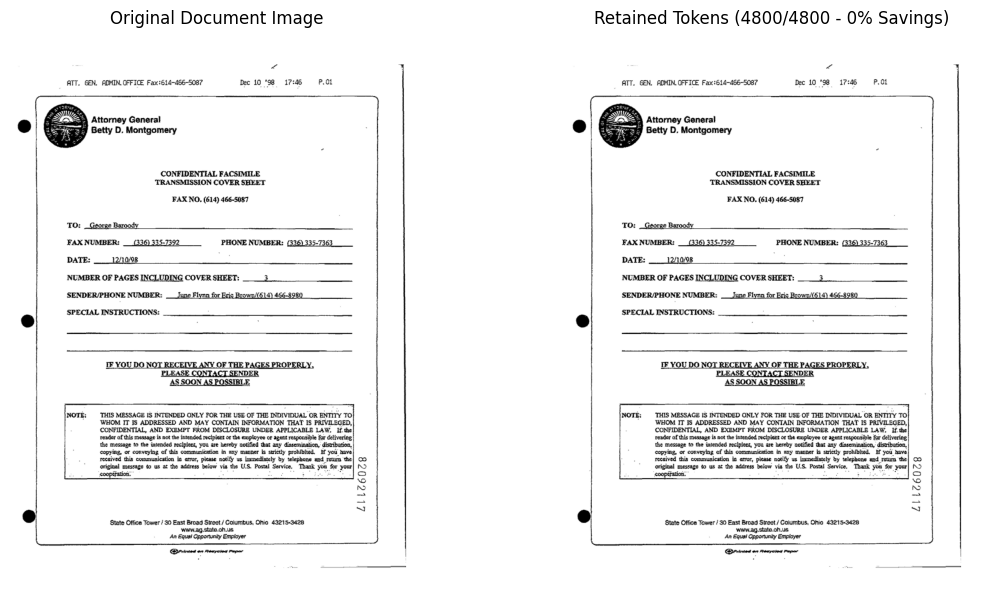

In [8]:
# Cell 8: Evaluation & Heatmap Plot
def compute_word_metrics(pred, gt_words):
    import re
    pw = re.findall(r'\w+', pred.lower())
    gold = re.findall(r'\w+', ' '.join(gt_words).lower())  # tokenize gold the same way
    gs = set(gold)
    recall = len(gs & set(pw)) / len(gs) if gs else 0.0
    try:
        import editdistance
        d = editdistance.eval(pw, gold)
    except Exception:
        d = abs(len(pw) - len(gold))
    order = max(0.0, 1.0 - d / max(len(pw), len(gold), 1))
    return recall, order


def compute_ned(pred, target):
    try:
        import editdistance
        d = editdistance.eval(pred, target)
    except Exception:
        d = sum(1 for a, b in zip(pred, target) if a != b) + abs(len(pred) - len(target))
    m = max(len(pred), len(target))
    return d / m if m > 0 else 0.0

model.eval()
test_raw = load_dataset('nielsr/funsd', split='test')  # all 50 test samples for stable metrics
neds, latencies, compression_ratios = [], [], []
recalls, word_orders = [], []
first_sample_meta = None

# Generation MUST be primed with the same task prompt the model was trained on
# (<s_doc>), otherwise it starts from the wrong token and produces junk.
TASK_PROMPT = '<s_doc>'
prompt_ids = processor.tokenizer(TASK_PROMPT, add_special_tokens=False, return_tensors='pt').input_ids.to(device)

for i, sample in enumerate(tqdm(test_raw, desc='Evaluating Test Set')):
    img = sample['image'].convert('RGB')
    pixel_values = processor(img, return_tensors='pt').pixel_values.to(device)
    words = sample.get('words', [])
    boxes = sample.get('bboxes') or sample.get('boxes')
    gt_words = reading_order_words(words, boxes)[:MAX_WORDS] if boxes else words[:MAX_WORDS]
    gt_str = json.dumps({'text': ' '.join(gt_words)})
    
    t0 = time.perf_counter()
    with torch.no_grad():
        gen_ids, meta = model.generate(pixel_values, decoder_input_ids=prompt_ids, max_length=512)
    latencies.append((time.perf_counter() - t0) * 1000.0)
    
    pred = processor.batch_decode(gen_ids, skip_special_tokens=True)[0]
    # Strip the echoed task prompt so we score only the generated content
    if pred.startswith(TASK_PROMPT):
        pred = pred[len(TASK_PROMPT):]
    pred = pred.strip()
    neds.append(compute_ned(pred, gt_str))
    rec, order = compute_word_metrics(pred, gt_words)
    recalls.append(rec)
    word_orders.append(order)
    compression_ratios.append(meta['compression_ratio'])
    if i == 0:
        first_sample_meta = (img, meta)
        # Print real text so success/failure is visible, not hidden behind a metric
        print('\n--- Sample 0 sanity check ---')
        print(f'PRED: {pred[:200]}')
        print(f'GT  : {gt_str[:200]}')
        print('-----------------------------')

print('\n' + '='*52)
print(f'[Stage 1] Word Recall (no missing words): {np.mean(recalls)*100:.2f}%')
print(f'[Stage 2] Character Accuracy:             {(1.0 - np.mean(neds))*100:.2f}%')
print(f'[Stage 3] Word-Order / Sequence Score:    {np.mean(word_orders)*100:.2f}%')
print(f'Mean Normalized Edit Distance (NED):      {np.mean(neds):.4f}')
print(f'Average Visual Token Savings:             {np.mean(compression_ratios):.1f}%')
print(f'Average Inference Latency:                {np.mean(latencies):.1f} ms/doc')
print('='*52)

# Visualize Overlay on First Sample
sample_img, meta = first_sample_meta
img_np = np.array(sample_img)
H, W, _ = img_np.shape
N = meta['original_tokens']
W_grid = int(round((N * (4/3)) ** 0.5))
H_grid = max(1, N // W_grid)
mask = np.zeros((H_grid, W_grid))
selected = set(meta['topk_indices'][0].cpu().numpy().tolist())
for idx in range(min(H_grid * W_grid, N)):
    if idx in selected:
        mask[idx // W_grid, idx % W_grid] = 1.0

mask_res = np.array(Image.fromarray((mask * 255).astype(np.uint8)).resize((W, H), Image.NEAREST)) / 255.0
overlay = img_np.copy().astype(np.float32)
overlay[mask_res < 0.5] *= 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_np)
axes[0].set_title('Original Document Image')
axes[0].axis('off')
axes[1].imshow(overlay.astype(np.uint8))
axes[1].set_title(f'Retained Tokens ({meta["compressed_tokens"]}/{N} - {meta["compression_ratio"]:.0f}% Savings)')
axes[1].axis('off')
plt.tight_layout()
os.makedirs('/kaggle/working', exist_ok=True)
plt.savefig('/kaggle/working/token_pruning_overlay.png', dpi=200)
plt.show()

In [9]:
# Cell 8b: Decoding ablation (EVAL-ONLY -- no retraining)
# Tests whether the stale generation config, not the model, caps word recall.
# repetition_penalty=1.3 + no_repeat_ngram_size=3 were tuned for AGGRESSIVE
# pruning ("repetition collapse"), but runs 2-5 all run keep_ratio=1.0 (pruning
# OFF). On full-page forms, trigram blocking is actively harmful: real documents
# repeat trigrams (form labels, phone numbers, dotted leaders), and once every
# continuation is blocked EOS becomes top-1, so the model stops mid-document.
# Re-evaluates the SAME weights under several decoding configs.
import re

# Row 0 is a CONTROL: it uses run 5's exact settings and must reproduce run 5's
# numbers. If it does not, this harness differs from the eval cell and NO other
# row is trustworthy -- the drift check below prints that verdict.
RUN5_REFERENCE = (50.56, 40.97, 26.49)  # recall / charAcc / order, FUNSD test x50
ABLATION_MAX_LEN = 512

DECODE_CONFIGS = [
    ('baseline (run5)',   dict(repetition_penalty=1.3, no_repeat_ngram_size=3)),
    ('no ngram block',    dict(repetition_penalty=1.3, no_repeat_ngram_size=0)),
    ('no rep penalty',    dict(repetition_penalty=1.0, no_repeat_ngram_size=3)),
    ('both off',          dict(repetition_penalty=1.0, no_repeat_ngram_size=0)),
    ('both off + minlen', dict(repetition_penalty=1.0, no_repeat_ngram_size=0, min_new_tokens=64)),
]


def run_decode_eval(label, overrides):
    """Re-run the FUNSD test set under one decoding config.

    Metrics mirror the eval cell exactly (same compute_word_metrics / compute_ned
    / reading_order_words / MAX_WORDS) so rows stay comparable to runs 2-5. The
    added length fields test the under-generation hypothesis directly rather than
    inferring it from recall.
    """
    model.eval()
    recs, ords_, neds_ = [], [], []
    pred_words, gold_words, gen_tokens = [], [], []
    json_ok, hit_cap = 0, 0

    for sample in tqdm(test_raw, desc=label, leave=False):
        img = sample['image'].convert('RGB')
        pv = processor(img, return_tensors='pt').pixel_values.to(device)
        words = sample.get('words', [])
        boxes = sample.get('bboxes') or sample.get('boxes')
        gt_words = reading_order_words(words, boxes)[:MAX_WORDS] if boxes else words[:MAX_WORDS]
        gt_str = json.dumps({'text': ' '.join(gt_words)})

        with torch.no_grad():
            gen_ids, _meta = model.generate(
                pv, decoder_input_ids=prompt_ids,
                max_length=ABLATION_MAX_LEN, **overrides
            )

        n_tok = int(gen_ids.shape[-1])
        gen_tokens.append(n_tok)
        if n_tok >= ABLATION_MAX_LEN:
            hit_cap += 1   # ran to the cap instead of emitting EOS

        pred = processor.batch_decode(gen_ids, skip_special_tokens=True)[0]
        if pred.startswith(TASK_PROMPT):
            pred = pred[len(TASK_PROMPT):]
        pred = pred.strip()

        # diagnostic only -- we never repair pred, that would score the fix
        try:
            json.loads(pred)
            json_ok += 1
        except Exception:
            pass

        r, o = compute_word_metrics(pred, gt_words)
        recs.append(r)
        ords_.append(o)
        neds_.append(compute_ned(pred, gt_str))
        pred_words.append(len(re.findall(r'\w+', pred.lower())))
        gold_words.append(len(re.findall(r'\w+', ' '.join(gt_words).lower())))

    n = max(len(recs), 1)
    mp, mg = float(np.mean(pred_words)), float(np.mean(gold_words))
    return {
        'config': label,
        'overrides': {k: v for k, v in overrides.items()},
        'word_recall_pct': float(np.mean(recs) * 100.0),
        'character_accuracy_pct': float((1.0 - np.mean(neds_)) * 100.0),
        'word_order_pct': float(np.mean(ords_) * 100.0),
        'mean_ned': float(np.mean(neds_)),
        'mean_pred_words': mp,
        'mean_gold_words': mg,
        'len_ratio_pct': 100.0 * mp / max(mg, 1e-9),
        'mean_gen_tokens': float(np.mean(gen_tokens)),
        'hit_max_length_pct': 100.0 * hit_cap / n,
        'valid_json_pct': 100.0 * json_ok / n,
        'num_eval_samples': len(recs),
    }


rows = []
for _name, _cfg in DECODE_CONFIGS:
    print(f'--- decoding: {_name}  {_cfg}')
    rows.append(run_decode_eval(_name, _cfg))

hdr = (f"{'config':20s} {'recall':>7s} {'charAcc':>8s} {'order':>7s} {'NED':>6s} "
       f"{'predW':>6s} {'goldW':>6s} {'len%':>6s} {'cap%':>5s} {'json%':>6s}")
print('\n' + '=' * len(hdr))
print(hdr)
print('-' * len(hdr))
for r in rows:
    print(f"{r['config']:20s} {r['word_recall_pct']:7.2f} {r['character_accuracy_pct']:8.2f} "
          f"{r['word_order_pct']:7.2f} {r['mean_ned']:6.3f} {r['mean_pred_words']:6.1f} "
          f"{r['mean_gold_words']:6.1f} {r['len_ratio_pct']:6.1f} "
          f"{r['hit_max_length_pct']:5.0f} {r['valid_json_pct']:6.1f}")
print('=' * len(hdr))

# --- CONTROL: does the baseline row reproduce run 5? ---
base = rows[0]
got = (base['word_recall_pct'], base['character_accuracy_pct'], base['word_order_pct'])
drift = max(abs(g - e) for g, e in zip(got, RUN5_REFERENCE))
print(f"\nCONTROL vs run 5 {RUN5_REFERENCE}")
print(f"  baseline got  ({got[0]:.2f}, {got[1]:.2f}, {got[2]:.2f})   max drift {drift:.2f} pts")
if drift < 0.5:
    print('  OK - harness reproduces run 5, so the other rows are comparable.')
else:
    print('  WARNING - harness does NOT match the run-5 eval (different weights, '
          'sampling, or transformers version). Treat other rows as suspect.')

# --- did loosening the decoder actually lengthen the output? ---
best = max(rows, key=lambda r: r['word_recall_pct'])
print(f"\nBest recall: '{best['config']}' at {best['word_recall_pct']:.2f}% "
      f"({best['word_recall_pct'] - base['word_recall_pct']:+.2f} vs baseline)")
print(f"  words emitted: {best['mean_pred_words']:.1f} vs baseline "
      f"{base['mean_pred_words']:.1f} (gold {base['mean_gold_words']:.1f})")
if best['config'] != base['config'] and best['mean_pred_words'] > base['mean_pred_words']:
    print('  => recall rose TOGETHER WITH length: under-generation was the cap.')
    print('     Re-run the Phase 2 pruning sweep with this config, not the stale one.')
elif best['config'] == base['config']:
    print('  => no config beat the baseline: the cap is NOT decoding. Look at the')
    print('     128-word target cap / encoder capacity instead (UNFREEZE_STAGES=2).')
else:
    print('  => recall rose WITHOUT more words: gain is fidelity, not coverage.')

with open('/kaggle/working/ablation_decoding.json', 'w') as f:
    json.dump(rows, f, indent=2)
print('\nWrote /kaggle/working/ablation_decoding.json')


--- decoding: baseline (run5)  {'repetition_penalty': 1.3, 'no_repeat_ngram_size': 3}


baseline (run5):   0%|          | 0/50 [00:00<?, ?it/s]

--- decoding: no ngram block  {'repetition_penalty': 1.3, 'no_repeat_ngram_size': 0}


no ngram block:   0%|          | 0/50 [00:00<?, ?it/s]

--- decoding: no rep penalty  {'repetition_penalty': 1.0, 'no_repeat_ngram_size': 3}


...

--- decoding: both off  {'repetition_penalty': 1.0, 'no_repeat_ngram_size': 0}


both off:   0%|          | 0/50 [00:00<?, ?it/s]

--- decoding: both off + minlen  {'repetition_penalty': 1.0, 'no_repeat_ngram_size': 0, 'min_new_tokens': 64}


both off + minlen:   0%|          | 0/50 [00:00<?, ?it/s]


config                recall  charAcc   order    NED  predW  goldW   len%  cap%  json%
--------------------------------------------------------------------------------------
baseline (run5)        50.56    40.97   26.49  0.590   80.5  113.0   71.3     0    0.0
no ngram block         50.56    40.97   26.49  0.590   80.5  113.0   71.3     0    0.0
no rep penalty         77.74    64.70   53.05  0.353  111.9  113.0   99.0     0   82.0
both off               71.03    59.16   51.30  0.408  140.8  113.0  124.6    22   70.0
both off + minlen      71.03    59.16   51.30  0.408  140.8  113.0  124.6    22   70.0

CONTROL vs run 5 (50.56, 40.97, 26.49)
  baseline got  (50.56, 40.97, 26.49)   max drift 0.00 pts
  OK - harness reproduces run 5, so the other rows are comparable.

Best recall: 'no rep penalty' at 77.74% (+27.18 vs baseline)
  words emitted: 111.9 vs baseline 80.5 (gold 113.0)
  => recall rose TOGETHER WITH length: under-generation was the cap.
     Re-run the Phase 2 pruning sweep wi

In [10]:
# Cell 8c: SELECTION ablation (EVAL-ONLY -- no retraining)
# Answers Pending 1b / 1c / 1d from AGENTS.md in one GPU session. Same weights, same
# decoder, same token BUDGET within a keep_ratio -- only the RANKING SIGNAL moves, so
# rows are comparable at equal cost.
#
# Two controls run at keep_ratio=1.0 (pruning OFF), and they are not the same check:
#   HARNESS CONTROL loads the run-5 weights that PRODUCED RUN6_REFERENCE and must
#     reproduce it. Nothing varies vs run 6, so drift here is the measurement --
#     harness, library version or sampling -- and nothing else is trustworthy.
#   Row 0 uses the weights actually being swept. Once the harness is verified, its
#     drift from run 6 is what the retrain did to unpruned accuracy.
# Runs 7-8 had only row 0, which retraining had turned into a two-variable test: its
# drift could not distinguish a broken harness from a changed checkpoint.
#
# 1b  keep=0.50 x {router, negated, random, ink}
#       random is the FLOOR: D1 measured the trained router as anti-correlated with
#       patch ink (r ~ -0.24), so uniform noise retains more text than the learned
#       scores. A router that cannot beat noise is not a router.
#       ink is the CEILING: patch contrast, no learning. It bounds what any
#       ink-seeking router could reach on this decoder. If it collapses, the premise
#       that half these tokens are droppable is wrong and Pending 1a is 4 wasted
#       GPU-hours. (Local CPU n=4: oracle 83.66 vs full page 83.67 -- premise holds.)
# 1d  keep=0.50 x {stratified, stratified_negated}
#       D2: the router's MINIMUM text-line ink coverage is 0.000 -- at least one line
#       loses all its ink -- while total retained ink looks unremarkable, and recall is
#       gated by the worst line. A per-grid-row budget makes that impossible. If these
#       rows fix the router, the bug is the SELECTION RULE, not the scorer, and
#       retraining is the wrong fix.
# 1c  keep in {1.00, 0.75, 0.50, 0.35}, each with its floor and ceiling
#       The accuracy/cost CURVE, with latency and token counts per row. GW=60 makes
#       the per-row budget integral at every ratio (60/45/30/21), so the stratified
#       rows are exact per-row top-k rather than the degradation path.
import os
import re
import time

RUN6_REFERENCE = (77.74, 64.70, 53.05)   # recall / charAcc / order, FUNSD test x50
SELECTION_MAX_LEN = 512
SELECTION_SEED = 0
GH, GW = 80, 60          # Swin-B token grid at 2560x1920, stride 32
ROW_INK_FRAC = 0.10     # a grid row counts as text if its ink >= 10% of the busiest
SELECTION_OUT = os.path.join(
    '/kaggle/working' if os.path.isdir('/kaggle/working') else '.',
    'ablation_selection.json')

SELECTION_CONFIGS = [
    ('keep=1.00 router CONTROL', 1.00, 'router'),
    # 1b
    ('keep=0.50 router',         0.50, 'router'),
    ('keep=0.50 NEGATED',        0.50, 'negated'),
    ('keep=0.50 random',         0.50, 'random'),
    ('keep=0.50 ink ORACLE',     0.50, 'ink'),
    # 1d
    ('keep=0.50 stratified',     0.50, 'stratified'),
    ('keep=0.50 strat NEGATED',  0.50, 'stratified_negated'),
    # 1c
    ('keep=0.75 router',         0.75, 'router'),
    ('keep=0.75 random',         0.75, 'random'),
    ('keep=0.75 ink ORACLE',     0.75, 'ink'),
    ('keep=0.75 strat NEGATED',  0.75, 'stratified_negated'),
    ('keep=0.35 router',         0.35, 'router'),
    ('keep=0.35 random',         0.35, 'random'),
    ('keep=0.35 ink ORACLE',     0.35, 'ink'),
    ('keep=0.35 strat NEGATED',  0.35, 'stratified_negated'),
]

# ---------------------------------------------------------------- MERGE ROWS (1e)
# The four-stage architecture (frozen Swin -> router prune -> ToMe merge -> decoder)
# running whole for the first time on a recorded result. Every previous run is
# prune-only at merge_ratio=0.0.
#
# Each merge row is paired with a PRUNE-ONLY TWIN at the identical final token count
# M, because "merging costs N points" is uninterpretable on its own: a merge row
# spends fewer tokens than its keep_ratio suggests, so an unpaired comparison charges
# merging for a budget cut. With M held fixed the question becomes answerable and
# bounded -- is merging to M cheaper in accuracy than pruning to the same M?
#
#   K = max(1, round(4800 * keep)),  r = min(round(K * merge), K // 2),  M = K - r
#
#   keep 1.00 m 0.20 -> K 4800  r 960  M 3840   == keep 0.80 prune-only
#   keep 0.50 m 0.20 -> K 2400  r 480  M 1920   == keep 0.40 prune-only
#   keep 0.35 m 0.20 -> K 1680  r 336  M 1344   == keep 0.28 prune-only
#   keep 0.50 m 0.40 -> K 2400  r 960  M 1440   == keep 0.30 prune-only
#
# BOTH router and ink arms, deliberately. The router is the known-weak selector -- it
# sits between the random floor and the ink ceiling -- so if merging only looks bad
# under the router we cannot separate "merging is destructive" from "the router's kept
# set is already so degraded that any further compression finishes it off". The ink
# pair is the clean mechanism test; the router pair is the deployed-system test.
#
# Ordering is not cosmetic: the JSON is rewritten after EVERY row, so pairing each
# merge row with its twin immediately means a session that dies mid-sweep leaves whole
# PAIRS behind. A merge row whose twin never ran answers nothing.
MERGE_CONFIGS = [
    # label                      keep  mode      merge  split
    ('keep=1.00 m=0.20 router',  1.00, 'router', 0.20, 'checkerboard'),
    ('keep=0.80 router TWIN',    0.80, 'router', 0.00, 'checkerboard'),
    ('keep=0.50 m=0.20 router',  0.50, 'router', 0.20, 'checkerboard'),
    ('keep=0.40 router TWIN',    0.40, 'router', 0.00, 'checkerboard'),
    ('keep=0.35 m=0.20 router',  0.35, 'router', 0.20, 'checkerboard'),
    ('keep=0.28 router TWIN',    0.28, 'router', 0.00, 'checkerboard'),
    ('keep=0.50 m=0.40 router',  0.50, 'router', 0.40, 'checkerboard'),
    ('keep=0.30 router TWIN',    0.30, 'router', 0.00, 'checkerboard'),
    ('keep=0.50 m=0.20 ink',     0.50, 'ink',    0.20, 'checkerboard'),
    ('keep=0.40 ink TWIN',       0.40, 'ink',    0.00, 'checkerboard'),
    ('keep=0.35 m=0.20 ink',     0.35, 'ink',    0.20, 'checkerboard'),
    ('keep=0.28 ink TWIN',       0.28, 'ink',    0.00, 'checkerboard'),
    # SABOTAGE / negative control, last: its comparison partner is the
    # keep=0.50 m=0.20 checkerboard row above, which by here has already run.
    # rank_parity reproduces the pre-2026-09-14 split exactly (grid_w=1 collapses the
    # checkerboard to sequence-position parity), at the same M and the same weights.
    ('keep=0.50 m=0.20 RANKPAR', 0.50, 'router', 0.20, 'rank_parity'),
]

# The 15 published selection rows are all prune-only and all checkerboard-by-default,
# so they widen to 5-tuples mechanically rather than being retyped.
ALL_CONFIGS = ([(n, k, m, 0.0, 'checkerboard') for n, k, m in SELECTION_CONFIGS]
               + MERGE_CONFIGS)

# (label, MERGE row key, PRUNE twin key). Keys are (keep, mode, merge, split) and
# (keep, mode) respectively; declared here beside the table above so the Q6 verdict
# and the row list cannot drift apart.
MERGE_PAIRS = [
    ('keep1.00 m0.20 vs keep0.80', (1.00, 'router', 0.20, 'checkerboard'), (0.80, 'router')),
    ('keep0.50 m0.20 vs keep0.40', (0.50, 'router', 0.20, 'checkerboard'), (0.40, 'router')),
    ('keep0.35 m0.20 vs keep0.28', (0.35, 'router', 0.20, 'checkerboard'), (0.28, 'router')),
    ('keep0.50 m0.40 vs keep0.30', (0.50, 'router', 0.40, 'checkerboard'), (0.30, 'router')),
    ('ink keep0.50 m0.20 vs 0.40', (0.50, 'ink', 0.20, 'checkerboard'), (0.40, 'ink')),
    ('ink keep0.35 m0.20 vs 0.28', (0.35, 'ink', 0.20, 'checkerboard'), (0.28, 'ink')),
]
SABOTAGE_PAIR = ('checkerboard vs rank_parity',
                 (0.50, 'router', 0.20, 'checkerboard'),
                 (0.50, 'router', 0.20, 'rank_parity'))

# Predicted M for every new row, from the arithmetic in the comment above. Checked
# against what ACTUALLY ran, because "the two rows of a pair agree on M" would still
# pass if both were wrong in the same way -- a processor change that altered N, say.
EXPECTED_M = {
    (1.00, 'router', 0.20, 'checkerboard'): 3840,
    (0.80, 'router', 0.00, 'checkerboard'): 3840,
    (0.50, 'router', 0.20, 'checkerboard'): 1920,
    (0.40, 'router', 0.00, 'checkerboard'): 1920,
    (0.35, 'router', 0.20, 'checkerboard'): 1344,
    (0.28, 'router', 0.00, 'checkerboard'): 1344,
    (0.50, 'router', 0.40, 'checkerboard'): 1440,
    (0.30, 'router', 0.00, 'checkerboard'): 1440,
    (0.50, 'ink', 0.20, 'checkerboard'): 1920,
    (0.40, 'ink', 0.00, 'checkerboard'): 1920,
    (0.35, 'ink', 0.20, 'checkerboard'): 1344,
    (0.28, 'ink', 0.00, 'checkerboard'): 1344,
    (0.50, 'router', 0.20, 'rank_parity'): 1920,
}


def line_coverage(pv, topk_indices):
    """Per-text-row retained-ink fractions for one image -> 1-D array, or None.

    D2 found that summed retained ink ranks `negated` ABOVE `random` while accuracy
    does the opposite, and that the WORST-covered text line is what tracks recall.
    That was 4 cached images against 4 aggregate rows -- one statistic ordering 4 rows
    correctly is 1-in-24 by luck. Recorded per image here so it becomes a real
    correlation that can actually fail.
    """
    N = GH * GW
    if pv.shape[-2] // 32 != GH or pv.shape[-1] // 32 != GW:
        return None            # non-standard grid; the accuracy row is still valid
    ink = patch_ink(pv, N)[0].reshape(GH, GW).float().cpu().numpy()
    keep = np.zeros(N, dtype=bool)
    keep[topk_indices[0].cpu().numpy()] = True
    keep2d = keep.reshape(GH, GW)
    row_ink = ink.sum(axis=1)
    is_text = row_ink >= ROW_INK_FRAC * row_ink.max()
    if not is_text.any():
        return None
    return (ink * keep2d).sum(axis=1)[is_text] / np.maximum(row_ink[is_text], 1e-9)


def run_selection_eval(label, keep_ratio, select_mode, merge_ratio=0.0,
                       tome_split='checkerboard'):
    """Re-run the FUNSD test set under one (keep_ratio, ranking signal) pair.

    Metrics mirror the eval cell exactly (same compute_word_metrics / compute_ned /
    reading_order_words / MAX_WORDS) so rows stay comparable to runs 2-6.
    """
    model.eval()
    # Reseed per row so the random control draws the same sequence on every run while
    # still getting a FRESH mask per image.
    torch.manual_seed(SELECTION_SEED)
    recs, ords_, neds_, inks, lats = [], [], [], [], []
    pred_words, gold_words, gen_tokens = [], [], []
    json_ok, hit_cap = 0, 0
    kept_tokens = None
    per_image = []

    for i, sample in enumerate(tqdm(test_raw, desc=label, leave=False)):
        img = sample['image'].convert('RGB')
        pv = processor(img, return_tensors='pt').pixel_values.to(device)
        words = sample.get('words', [])
        boxes = sample.get('bboxes') or sample.get('boxes')
        gt_words = reading_order_words(words, boxes)[:MAX_WORDS] if boxes else words[:MAX_WORDS]
        gt_str = json.dumps({'text': ' '.join(gt_words)})

        t0 = time.perf_counter()
        with torch.no_grad():
            gen_ids, meta = model.generate(
                pv, decoder_input_ids=prompt_ids, keep_ratio=keep_ratio,
                merge_ratio=merge_ratio, max_length=SELECTION_MAX_LEN,
                select_mode=select_mode, tome_split=tome_split
            )
        lats.append((time.perf_counter() - t0) * 1000.0)
        kept_tokens = meta['compressed_tokens']
        if meta['retained_ink'] is not None:
            inks.append(meta['retained_ink'])
        cov = line_coverage(pv, meta['topk_indices'])

        n_tok = int(gen_ids.shape[-1])
        gen_tokens.append(n_tok)
        if n_tok >= SELECTION_MAX_LEN:
            hit_cap += 1   # ran to the cap instead of emitting EOS

        pred = processor.batch_decode(gen_ids, skip_special_tokens=True)[0]
        if pred.startswith(TASK_PROMPT):
            pred = pred[len(TASK_PROMPT):]
        pred = pred.strip()

        # diagnostic only -- we never repair pred, that would score the fix
        try:
            json.loads(pred)
            json_ok += 1
        except Exception:
            pass

        r, o = compute_word_metrics(pred, gt_words)
        recs.append(r)
        ords_.append(o)
        neds_.append(compute_ned(pred, gt_str))
        pred_words.append(len(re.findall(r'\w+', pred.lower())))
        gold_words.append(len(re.findall(r'\w+', ' '.join(gt_words).lower())))
        per_image.append({
            'i': i,
            'tokens': int(meta['compressed_tokens']),
            'recall': float(r),
            'ned': float(neds_[-1]),
            'retained_ink': meta['retained_ink'],
            'gen_tokens': n_tok,
            'min_line_cov': None if cov is None else float(cov.min()),
            'p10_line_cov': None if cov is None else float(np.percentile(cov, 10)),
            'mean_line_cov': None if cov is None else float(cov.mean()),
            'n_text_rows': None if cov is None else int(cov.size),
        })

    n = max(len(recs), 1)
    mp, mg = float(np.mean(pred_words)), float(np.mean(gold_words))
    # Every distinct M this row actually produced. 'visual_tokens' below is the
    # last image's value and is kept as-is so the published rows stay comparable;
    # this is the field that makes a non-constant M visible instead of hidden.
    tok_distinct = sorted({p['tokens'] for p in per_image})
    covs = [p['min_line_cov'] for p in per_image if p['min_line_cov'] is not None]
    return {
        'config': label,
        'keep_ratio': keep_ratio,
        'select_mode': select_mode,
        'merge_ratio': merge_ratio,
        'tome_split': tome_split,
        'visual_tokens': kept_tokens,
        'visual_tokens_distinct': tok_distinct,
        'retained_ink': float(np.mean(inks)) if inks else None,
        'mean_min_line_cov': float(np.mean(covs)) if covs else None,
        'word_recall_pct': float(np.mean(recs) * 100.0),
        'character_accuracy_pct': float((1.0 - np.mean(neds_)) * 100.0),
        'word_order_pct': float(np.mean(ords_) * 100.0),
        'mean_ned': float(np.mean(neds_)),
        'mean_pred_words': mp,
        'mean_gold_words': mg,
        'len_ratio_pct': 100.0 * mp / max(mg, 1e-9),
        'mean_gen_tokens': float(np.mean(gen_tokens)),
        'hit_max_length_pct': 100.0 * hit_cap / n,
        'valid_json_pct': 100.0 * json_ok / n,
        'avg_latency_ms': float(np.mean(lats)),
        'num_eval_samples': len(recs),
        'per_image': per_image,
    }


_t0 = time.perf_counter()

# ---------------------------------------------------------------- HARNESS CONTROL
# The row-0 CONTROL below re-runs a known SETTING; this block re-runs a known
# CHECKPOINT. Runs 7-8 retrained before row 0 ran, so row 0's drift from run 6
# conflated "the harness moved" with "the weights moved". Evaluating the run-5
# weights -- the ones that produced RUN6_REFERENCE -- through this exact function
# varies nothing vs run 6, so any drift HERE is harness/version/sampling, and row
# 0's drift is then the retrain alone. keep_ratio=1.0 prunes nothing, so this row
# is also independent of every selection code path under test.
HARNESS_CONTROL_TOL = 0.5
_ctrl_ckpt = globals().get('RESUME_CKPT') or None
_eval_ckpt = globals().get('EVAL_CKPT') or _ctrl_ckpt
_retrained = bool(globals().get('DO_TRAIN', False))
harness_row, harness_verified, harness_note = None, None, ''


def _weight_fingerprint(m):
    """Deterministic checksum over EVERY parameter, not a sample of them.

    A sample can miss the swap: the first/middle/last keys of a Donut state dict are
    frozen encoder tensors that training never touches, so a 3-key fingerprint would
    compare equal across two genuinely different checkpoints. Cost is one .sum() per
    tensor, milliseconds on GPU, and only precision-stable equality is needed here.
    """
    return tuple(float(v.detach().float().sum()) for _, v in sorted(m.state_dict().items()))


if not _retrained:
    harness_note = ('skipped: DO_TRAIN is off, so `model` still holds the control weights '
                    'and row 0 below already IS the harness control.')
    print(f'\nHARNESS CONTROL {harness_note}')
elif not (_ctrl_ckpt and os.path.exists(_ctrl_ckpt)):
    harness_note = f'skipped: control checkpoint not found ({_ctrl_ckpt!r})'
    print(f'\nHARNESS CONTROL {harness_note}')
else:
    print(f'\n--- HARNESS CONTROL: run-5 weights through this harness')
    print(f'    control  {_ctrl_ckpt}')
    print(f'    restore  {_eval_ckpt}')
    _fp_swept = _weight_fingerprint(model)
    _sd = torch.load(_ctrl_ckpt, map_location='cpu', weights_only=True)
    _miss, _unex = model.load_state_dict(_sd, strict=False)
    assert not _miss and not _unex, (
        f'control checkpoint does not match this architecture: {len(_miss)} missing, '
        f'{len(_unex)} unexpected (missing {_miss[:3]}, unexpected {_unex[:3]}). A partial '
        f'load would evaluate a partly-random model and call the drift a control.')
    assert _weight_fingerprint(model) != _fp_swept, (
        'control load changed nothing -- RESUME_CKPT and the swept weights are the same '
        'tensors, so this row would not be a control.')

    harness_row = run_selection_eval('HARNESS CONTROL run-5 wts', 1.00, 'router')

    # Restore BEFORE reporting, so a restore failure cannot be mistaken for a
    # reporting failure and so the assert below fires while the cause is on screen.
    _sd2 = torch.load(_eval_ckpt, map_location='cpu', weights_only=True)
    _m2, _u2 = model.load_state_dict(_sd2, strict=False)
    assert not _m2 and not _u2, (
        f'restore checkpoint does not match: {len(_m2)} missing, {len(_u2)} unexpected')
    assert _weight_fingerprint(model) == _fp_swept, (
        'FAILED TO RESTORE the swept weights. Every row below would measure the control '
        'checkpoint instead, and the table would look entirely plausible. Refusing to '
        'produce it.')
    del _sd, _sd2
    print('    weights restored and fingerprint-verified')

    _hgot = (harness_row['word_recall_pct'], harness_row['character_accuracy_pct'],
             harness_row['word_order_pct'])
    _hdrift = max(abs(g - e) for g, e in zip(_hgot, RUN6_REFERENCE))
    harness_verified = bool(_hdrift < HARNESS_CONTROL_TOL)
    print(f'    got ({_hgot[0]:.2f}, {_hgot[1]:.2f}, {_hgot[2]:.2f})  vs run 6 '
          f'{RUN6_REFERENCE}  max drift {_hdrift:.2f} pts')
    if harness_verified:
        harness_note = f'verified: run-5 weights reproduce run 6 within {_hdrift:.2f} pts'
        print('    HARNESS OK - the same weights reproduce run 6 through this code, so '
              'row 0\'s')
        print('    drift below is the RETRAIN, not the measurement.')
    else:
        harness_note = (f'FAILED: run-5 weights drift {_hdrift:.2f} pts from run 6 through '
                        f'this harness')
        print('    ' + '!' * 70)
        print('    HARNESS CONTROL FAILED. The weights that produced run 6 do NOT')
        print('    reproduce it here, so nothing below is quotable against run 6 or any')
        print('    earlier run in absolute terms. Rows stay comparable TO EACH OTHER')
        print('    (same harness, same weights, only the ranking signal varies), which')
        print('    is what Q1/Q2/Q4 ask -- so the sweep continues instead of discarding')
        print('    the session. Results are stamped harness_verified=false.')
        print('    ' + '!' * 70)

rows = []

# ------------------------------------------------------------------- PROVENANCE
# What produced the rows below, stamped into the JSON at BOTH write sites. The
# settings of a run were already recorded; the ENVIRONMENT was not, and that is the
# axis every cross-run comparison in this project has broken on (D11/D12: local
# generation drifts up to 3.4 pts from Kaggle on bit-identical selections, different
# device and transformers version). mtime+size as well as the path, because run
# directories get renamed and a bare path stops identifying the file.
#
# Nothing here may raise: provenance is bookkeeping, and bookkeeping must not be able
# to cost a 40-minute GPU session. Every lookup degrades to a string instead.
try:
    import transformers as _tfm_prov
    _tfm_ver = _tfm_prov.__version__
except Exception as _e:                       # noqa: BLE001 - report, never raise
    _tfm_ver = f'unavailable ({type(_e).__name__})'


def _ckpt_stamp(p):
    """Path + mtime + size for a checkpoint, or an explicit reason there is none.

    Returns a dict on every path, including failure. A MISSING key in the JSON means
    "written before provenance existed"; a PRESENT key carrying 'error' means "we
    looked and it was not there". Collapsing both to None discards exactly the
    distinction that matters when reading a stale artifact months later.
    """
    if not p:
        return {'path': None,
                'error': 'no checkpoint variable set (EVAL_CKPT / RESUME_CKPT)'}
    try:
        _st = os.stat(p)
    except OSError as e:
        return {'path': str(p), 'error': f'{type(e).__name__}: {e}'}
    return {'path': str(p),
            'mtime': time.strftime('%Y-%m-%dT%H:%M:%SZ', time.gmtime(_st.st_mtime)),
            'size_bytes': int(_st.st_size)}


try:
    _dev_prov = str(next(model.parameters()).device)
except Exception:                             # noqa: BLE001 - NameError / StopIteration
    _dev_prov = 'unknown'
if _dev_prov.startswith('cuda'):
    try:
        _devname_prov = torch.cuda.get_device_name(_dev_prov)
    except Exception:                         # noqa: BLE001
        _devname_prov = 'cuda (name unavailable)'
elif _dev_prov == 'unknown':
    _devname_prov = 'unknown'
else:
    _devname_prov = 'cpu'

PROVENANCE = {
    'eval_ckpt': _ckpt_stamp(_eval_ckpt),
    'control_ckpt': _ckpt_stamp(_ctrl_ckpt),
    'transformers': _tfm_ver,
    'torch': getattr(torch, '__version__', 'unknown'),
    'device': _dev_prov,
    'device_name': _devname_prov,
    'written': time.strftime('%Y-%m-%dT%H:%M:%SZ', time.gmtime()),
}
# Serialise once HERE rather than discovering at the first write that something in the
# dict is not JSON-able -- that write lands after row 0, i.e. minutes of GPU in.
json.dumps(PROVENANCE)
print(f"\nPROVENANCE  torch {PROVENANCE['torch']}  transformers "
      f"{PROVENANCE['transformers']}  {PROVENANCE['device']} ({PROVENANCE['device_name']})")
print(f"    eval ckpt     {PROVENANCE['eval_ckpt']}")
print(f"    control ckpt  {PROVENANCE['control_ckpt']}")

for _name, _kr, _mode, _mr, _split in ALL_CONFIGS:
    print(f'--- {_name}')
    rows.append(run_selection_eval(_name, _kr, _mode, _mr, _split))
    _r = rows[-1]
    _ink = '  -  ' if _r['retained_ink'] is None else f"{_r['retained_ink']:.3f}"
    print(f"    -> recall {_r['word_recall_pct']:.2f}  charAcc "
          f"{_r['character_accuracy_pct']:.2f}  ink {_ink}  "
          f"{_r['avg_latency_ms']:.0f} ms/img  [{(time.perf_counter() - _t0) / 60:.1f} min]")
    # Written after EVERY row: a Kaggle session that dies at row 12 must not lose
    # rows 0-11 the way the local run did.
    with open(SELECTION_OUT, 'w') as f:
        json.dump({'meta': {'run6_reference': RUN6_REFERENCE,
                            'seed': SELECTION_SEED,
                            'max_len': SELECTION_MAX_LEN,
                            'harness_verified': harness_verified,
                            'harness_note': harness_note,
                            'harness_control': harness_row,
                            'provenance': PROVENANCE,
                            'complete': False}, 'rows': rows}, f, indent=2)

hdr = (f"{'config':26s} {'tok':>5s} {'ink':>5s} {'minCov':>6s} {'recall':>7s} "
       f"{'charAcc':>8s} {'order':>7s} {'NED':>6s} {'len%':>6s} {'cap%':>5s} "
       f"{'json%':>6s} {'ms':>7s}")
print('\n' + '=' * len(hdr))
print(hdr)
print('-' * len(hdr))
for r in rows:
    ink = '  -  ' if r['retained_ink'] is None else f"{r['retained_ink']:.3f}"
    mc = '  -  ' if r['mean_min_line_cov'] is None else f"{r['mean_min_line_cov']:.3f}"
    print(f"{r['config']:26s} {r['visual_tokens']:5d} {ink:>5s} {mc:>6s} "
          f"{r['word_recall_pct']:7.2f} {r['character_accuracy_pct']:8.2f} "
          f"{r['word_order_pct']:7.2f} {r['mean_ned']:6.3f} {r['len_ratio_pct']:6.1f} "
          f"{r['hit_max_length_pct']:5.0f} {r['valid_json_pct']:6.1f} "
          f"{r['avg_latency_ms']:7.0f}")
print('=' * len(hdr))

# --- CONTROL: does keep_ratio=1.0 on the SWEPT weights reproduce run 6? ---
# Read this together with the HARNESS CONTROL above. That block fixed the weights and
# varied nothing; this one fixes the setting and varies the weights. The pair is what
# makes a drift attributable: harness verified + row 0 drifting = the retrain moved the
# ceiling. Both drifting = measurement problem, and the retrain's effect is unreadable.
ctrl = rows[0]
got = (ctrl['word_recall_pct'], ctrl['character_accuracy_pct'], ctrl['word_order_pct'])
drift = max(abs(g - e) for g, e in zip(got, RUN6_REFERENCE))
print(f'\nCONTROL vs run 6 {RUN6_REFERENCE}')
print(f'  got ({got[0]:.2f}, {got[1]:.2f}, {got[2]:.2f})   max drift {drift:.2f} pts')
if drift < 0.5:
    print('  OK - this checkpoint matches run 6 at keep=1.0, so every other row is '
          'comparable.')
elif harness_verified:
    print(f'  DIFFERENT CEILING - and the harness was verified above, so this '
          f'{drift:.2f} pt gap')
    print('  is what the retrain did to unpruned accuracy, not measurement noise. Compare '
          'rows to THIS row, not to run 6.')
else:
    print('  WARNING - harness does NOT match run 6 (different weights, sampling, or '
          'transformers version). Rows are still comparable TO EACH OTHER and to this '
          'control, but do not quote them against run 6 absolutely.')
    if harness_verified is False:
        print('  The HARNESS CONTROL above also failed, so this gap cannot be attributed '
              'to the retrain.')

by = {(r['keep_ratio'], r['select_mode']): r
      for r in rows if r.get('merge_ratio', 0.0) == 0.0}
# Q6 needs the merge rows, so it gets its own index on the full four-part key.
by_all = {(r['keep_ratio'], r['select_mode'], r.get('merge_ratio', 0.0),
           r.get('tome_split', 'checkerboard')): r for r in rows}
assert len(by_all) == len(rows), (
    f'duplicate (keep, mode, merge, split) key among {len(rows)} rows -- a row is\n'
    f'shadowing another and Q6 would compare the wrong pair: '\
    f'{len(rows) - len(by_all)} collision(s)')


def rec(kr, mode):
    r = by.get((kr, mode))
    return None if r is None else r['word_recall_pct']


# --- Q1 (1b): does negating the router help? ---
print('\nQ1. Does negating the router help? (keep=0.50)')
for m in ('router', 'negated', 'random'):
    r = by[(0.50, m)]
    print(f"  {m:8s} {r['word_recall_pct']:6.2f} recall   ink {r['retained_ink']:.3f}"
          f"   minCov {r['mean_min_line_cov']:.3f}")
if rec(0.50, 'negated') > max(rec(0.50, 'router'), rec(0.50, 'random')):
    print('  => NEGATION IS A REAL FIX: it beats the forward router AND random, so '
          'flipping the sign makes the existing checkpoint usable.')
else:
    print('  => negation does not beat random: retaining ink is NECESSARY BUT NOT '
          'SUFFICIENT (D2). Do not adopt it as the fix.')

# --- Q2 (1b): is the premise sound at all? ---
print('\nQ2. Are half these tokens droppable at all? (the row that can kill 1a)')
print(f"  keep=1.00 CONTROL  {rec(1.00, 'router'):6.2f} recall  ({ctrl['visual_tokens']} tokens)")
_ik = by[(0.50, 'ink')]
print(f"  keep=0.50 ORACLE   {_ik['word_recall_pct']:6.2f} recall  "
      f"({_ik['visual_tokens']} tokens, ink {_ik['retained_ink']:.3f})   "
      f"{_ik['word_recall_pct'] - ctrl['word_recall_pct']:+.2f} vs control")
if _ik['word_recall_pct'] > ctrl['word_recall_pct'] - 5.0:
    print('  => PREMISE HOLDS: an ink-ranked half of the tokens nearly matches the '
          'full page, so the headroom a trained router could reach is real.')
else:
    print('  => PREMISE IS WEAK: even a perfect ink ranking loses accuracy at this '
          'budget. Cap expectations for ANY router and consider merge_ratio (which '
          'compresses rather than discards) before more pruning work.')
print(f"  at keep=0.50 the router sits at {rec(0.50, 'router'):.2f}, between a floor of "
      f"{rec(0.50, 'random'):.2f} (random) and a ceiling of {_ik['word_recall_pct']:.2f} (oracle).")

# --- Q4 (1d): is the SELECTION RULE the bug, or the scorer? ---
print('\nQ4. Is the bug the selection RULE or the scorer? (keep=0.50, D2/Pending 1d)')
for m in ('router', 'stratified', 'stratified_negated', 'random', 'ink'):
    r = by[(0.50, m)]
    print(f"  {m:19s} {r['word_recall_pct']:6.2f} recall   ink {r['retained_ink']:.3f}"
          f"   minCov {r['mean_min_line_cov']:.3f}")
_best_strat = max(rec(0.50, 'stratified'), rec(0.50, 'stratified_negated'))
if _best_strat >= rec(0.50, 'random'):
    print('  => THE SELECTION RULE WAS THE BUG. A per-row budget on the SAME scores '
          'reaches the random floor or better, so the scorer is salvageable and 1a '
          'should train WITH stratified selection rather than replace the scorer.')
elif _best_strat > rec(0.50, 'router') + 2.0:
    print('  => PARTIAL: stratification helps but does not reach random, so the rule '
          'is one cause and the scorer is another. 1a still needed; keep the per-row '
          'budget in it.')
else:
    print('  => NOT THE RULE. Bounding worst-case coverage does not rescue these '
          'scores, so the scorer itself is what is broken -- Pending 1a (train with '
          'pruning ON) is the fix, and D2 says its loss must NOT reward summed '
          'retained saliency.')

# --- Q5 (1c): the accuracy/cost curve ---
print('\nQ5. keep_ratio curve (Pending 1c) -- recall by ranking signal, cost per row')
print(f"  {'keep':>5s} {'tok':>5s} {'router':>7s} {'random':>7s} {'oracle':>7s} "
      f"{'stratN':>7s} {'ms/img':>7s}")
for kr in (1.00, 0.75, 0.50, 0.35):
    r0 = by.get((kr, 'router'))
    if r0 is None:
        continue
    cells_ = []
    for m in ('router', 'random', 'ink', 'stratified_negated'):
        v = rec(kr, m)
        cells_.append('      -' if v is None else f'{v:7.2f}')
    print(f"  {kr:5.2f} {r0['visual_tokens']:5d} " + ' '.join(cells_) +
          f" {r0['avg_latency_ms']:7.0f}")
print('  NOTE: there is NO encoder-side saving. The router runs AFTER the frozen')
print('        Swin, so all 4800 tokens are computed at every keep_ratio; the only')
print('        saving is decoder cross-attention KV length.')
print('  NOTE: latency is decoder-bound. D11 (n=50, 5 budgets, 2 checkpoints)')
print('        measured 4800 -> 960 tokens buying 1.04x wall-clock (1.05x max),')
print('        because generation runs 243-280 autoregressive steps while the')
print('        encoder runs once. The tok column is a TOKEN-COUNT axis, not an')
print('        efficiency one; any latency or throughput claim is false.')

# --- Q3 (D2): which statistic predicts recall? ---
# D2 claimed WORST-CASE line coverage discriminates where summed retained ink does
# not, but measured it on 4 cached images against 4 aggregate rows. Here it is a
# per-image test over every equal-budget row, so it can actually fail.
def spearman(a, b):
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    if a.size < 3 or np.ptp(a) == 0 or np.ptp(b) == 0:
        return float('nan')
    ra = np.argsort(np.argsort(a)).astype(float)
    rb = np.argsort(np.argsort(b)).astype(float)
    return float(np.corrcoef(ra, rb)[0, 1])


# Merge rows are EXCLUDED, not merely unfiltered. Both predictors here
# (`retained_ink`, `min_line_cov`) are computed PRE-merge -- gathered on
# topk_indices -- while `recall` is post-merge, so a merge row contributes a record
# whose predictor is identical to its prune twin's and whose outcome is not. That is
# pure noise injected exactly where the D2 verdict turns on a 0.05 rho gap.
# NOTE the prune-only TWIN rows (keep 0.80/0.40/0.30/0.28) DO enter the pool and
# legitimately so -- they are ordinary pruned rows at new budgets -- which means
# Q3's numbers are not directly comparable to run 9/10's 15-row pool.
pooled = [(p, r['select_mode']) for r in rows
          if r['keep_ratio'] < 1.0 and r.get('merge_ratio', 0.0) == 0.0
          for p in r['per_image'] if p['min_line_cov'] is not None]
if len(pooled) >= 12:
    _rec = [p['recall'] for p, _ in pooled]
    print(f'\nQ3. Which statistic predicts per-image recall? (all pruned rows, n={len(pooled)})')
    print(f"  {'statistic':22s} {'family':12s} {'Spearman vs recall':>19s}")
    print('  ' + '-' * 56)
    for key, fam in (('retained_ink', 'aggregate'), ('mean_line_cov', 'aggregate'),
                     ('p10_line_cov', 'worst-case'), ('min_line_cov', 'worst-case')):
        print(f'  {key:22s} {fam:12s} '
              f'{spearman([p[key] for p, _ in pooled], _rec):19.3f}')
    rho_ink = spearman([p['retained_ink'] for p, _ in pooled], _rec)
    rho_min = spearman([p['min_line_cov'] for p, _ in pooled], _rec)
    if rho_min > rho_ink + 0.05:
        print('  => D2 CONFIRMED per-image: worst-case coverage predicts recall better '
              'than summed ink. Do NOT build a router objective on total retained '
              'saliency.')
    elif rho_ink > rho_min + 0.05:
        print('  => D2 FALSIFIED per-image: summed ink is the better predictor after '
              'all. D2 was a 4-row coincidence; revise it and re-check 1a/1d.')
    else:
        print('  => INCONCLUSIVE: the two families predict about equally well here, so '
              "D2's claim stands unconfirmed rather than refuted.")
    # Within-mode is the harder test: it removes the between-mode contrast that could
    # carry the pooled correlation on its own.
    print('\n  within-mode (controls for the mode -- image-to-image variation only):')
    for mode in ('router', 'negated', 'random', 'ink', 'stratified', 'stratified_negated'):
        sub_ = [p for p, m in pooled if m == mode]
        if len(sub_) >= 5:
            print(f"    {mode:19s} ink "
                  f"{spearman([p['retained_ink'] for p in sub_], [p['recall'] for p in sub_]):6.3f}"
                  f"   min-cov "
                  f"{spearman([p['min_line_cov'] for p in sub_], [p['recall'] for p in sub_]):6.3f}"
                  f"   (n={len(sub_)})")
else:
    print('\nQ3 skipped: too few per-image coverage records to correlate.')

# --- Q6 (1e): token-matched merge vs prune -- the whole architecture at equal cost ---
# The question this sweep exists to answer, stated so it can fail: on a merge-naive
# checkpoint, does compressing to M tokens by MERGING cost less accuracy than
# compressing to the same M by PRUNING? Holding M fixed is what makes it answerable;
# an unpaired "merging costs N points" charges merging for a budget cut it did not ask
# for.
#
# FRAMING, stated BEFORE the numbers so it cannot be fitted to them: every checkpoint
# in this project was trained at merge_ratio=0.0, so inference-time merging is
# OFF-DISTRIBUTION. By D12's own logic a negative result is EXPECTED and is NOT
# evidence that ToMe is worthless -- it is the H1 train/test-matching lesson a second
# time. What a negative result does license is refusing to adopt merging as a drop-in
# at inference; what a positive or near-neutral result licenses is training with
# merging on, which is the follow-up and is not in this run.
#
# RESOLUTION, also stated before the numbers: runs 9-11 put this harness's paired 95%
# half-width at roughly 2-4 pts on n=50 FUNSD documents. A |delta| under ~3 pts is
# BELOW WHAT THIS SWEEP CAN SEE and must be read as indistinguishable -- not as a
# small win, and not as a small loss.
#
# This constant is a PRE-REGISTERED BAR, not a measurement, and the two must not be
# confused: every row below also prints its OWN half-width, and a flat row whose own
# resolution exceeds this bar is reported UNDERPOWERED rather than null. Run 11's
# post-mortem is the reason -- its pre-registration set MIN_EFFECT_PTS = 3.0 against
# rows whose actual resolution was 4.6-5.6, so one verdict was unreachable before a
# single image was decoded, and the prose would have called it a null.
Q6_RESOLUTION_PTS = 3.0


def paired_recall_delta(row_a, row_b, n_boot=10000, seed=0):
    """mean(recall_a - recall_b) over the SAME documents + 95% bootstrap CI.

    Paired by document index: both rows saw the identical 50 FUNSD pages, and
    between-document variance dwarfs the effect under test, so an unpaired CI would be
    several times too wide to resolve anything. Resamples DOCUMENTS, which is the
    population the conclusion generalises over.

    Returns (mean, lo, hi, n, resolution) where resolution is the CI HALF-WIDTH -- the
    smallest effect this pair could have resolved. It is returned rather than assumed
    so no verdict string can claim a precision the data does not have.
    """
    a = {p['i']: p['recall'] for p in row_a['per_image']}
    b = {p['i']: p['recall'] for p in row_b['per_image']}
    shared = sorted(set(a) & set(b))
    d = np.array([a[i] - b[i] for i in shared], dtype=float) * 100.0
    if d.size < 3:
        return (float('nan'),) * 3 + (int(d.size), float('nan'))
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, d.size, size=(n_boot, d.size))
    boots = d[idx].mean(axis=1)
    lo = float(np.percentile(boots, 2.5))
    hi = float(np.percentile(boots, 97.5))
    return float(d.mean()), lo, hi, int(d.size), (hi - lo) / 2.0


def assert_token_matched(label, row_m, row_p):
    """Hard stop if the two rows did not actually land on the same M.

    An assert, not a warning. The whole Q6 comparison is "same token count, different
    way of getting there"; if M differs then the delta is a budget effect wearing a
    merging costume, and a table that prints it anyway is worse than no table -- it
    reads exactly like the real thing. Checked PER IMAGE because 'visual_tokens'
    records only the last one, and absolutely against EXPECTED_M because two rows can
    agree on an M that is wrong for both.
    """
    tm = [p['tokens'] for p in row_m['per_image']]
    tp = [p['tokens'] for p in row_p['per_image']]
    assert tm and tm == tp, (
        f'{label}: NOT token-matched. merge row M {sorted(set(tm))} (n={len(tm)}) vs '
        f'prune row M {sorted(set(tp))} (n={len(tp)}). The delta would measure the '
        f'token budget, not merging.')
    for _r in (row_m, row_p):
        _exp = EXPECTED_M.get((_r['keep_ratio'], _r['select_mode'],
                               _r.get('merge_ratio', 0.0),
                               _r.get('tome_split', 'checkerboard')))
        _got = sorted({p['tokens'] for p in _r['per_image']})
        assert _exp is None or _got == [_exp], (
            f"{label}: row {_r['config']!r} ran at M={_got}, predicted {_exp}. Both "
            f'rows of a pair agreeing on a WRONG M passes the match check above, so '
            f'the arithmetic is checked absolutely too.')
    return tm[0]


q6_rows = []
_q6_hdr = (f"  {'pair':28s} {'M':>5s} {'merge':>7s} {'prune':>7s} {'delta':>7s} "
           f"{'95% CI':>18s} {'res':>5s}  verdict")
print('\n' + '=' * 112)
print('Q6. TOKEN-MATCHED: merge to M vs prune to the same M   (paired by document, '
      '95% bootstrap CI)')
print('=' * 112)
print(_q6_hdr)
print('  ' + '-' * 108)
for _lbl, _mkey, _pkey in MERGE_PAIRS:
    _rm = by_all.get(_mkey)
    _rp = by_all.get(_pkey + (0.0, 'checkerboard'))
    if _rm is None or _rp is None:
        print(f"  {_lbl:28s} MISSING -- merge row "
              f"{'ran' if _rm is not None else 'ABSENT'}, twin "
              f"{'ran' if _rp is not None else 'ABSENT'} (session ended before both)")
        continue
    _M = assert_token_matched(_lbl, _rm, _rp)
    _d, _lo, _hi, _n, _res = paired_recall_delta(_rm, _rp)
    _sig = (_lo > 0) or (_hi < 0)
    # A flat row is only a null if it COULD have shown the effect. _res is this pair's
    # own measured half-width, so the two flat cases are separated by data rather than
    # by the bar: below the bar the row genuinely says "no difference this large",
    # above it the row says nothing at all.
    _under = (not _sig) and _res > Q6_RESOLUTION_PTS
    if _under:
        _v = (f'UNDERPOWERED (res {_res:.1f} > {Q6_RESOLUTION_PTS:.1f} pts bar) '
              f'-- not a null')
    elif not _sig:
        _v = f'indistinguishable (res {_res:.1f} pts at n={_n})'
    elif _d > 0:
        _v = 'MERGING WINS at equal M'
    else:
        _v = 'merging LOSES at equal M'
    print(f"  {_lbl:28s} {_M:5d} {_rm['word_recall_pct']:7.2f} "
          f"{_rp['word_recall_pct']:7.2f} {_d:+7.2f} "
          f"{f'[{_lo:+.2f}, {_hi:+.2f}]':>18s} {_res:5.1f}  {_v}")
    q6_rows.append({'pair': _lbl, 'tokens': _M,
                    'merge_config': _rm['config'], 'prune_config': _rp['config'],
                    'merge_recall_pct': _rm['word_recall_pct'],
                    'prune_recall_pct': _rp['word_recall_pct'],
                    'delta_pts': _d, 'ci95_lo': _lo, 'ci95_hi': _hi,
                    'resolution_pts': _res, 'n_paired': _n,
                    'significant': bool(_sig), 'underpowered': bool(_under)})
print('=' * 112)

if q6_rows:
    _wins = [q for q in q6_rows if q['significant'] and q['delta_pts'] > 0]
    _loss = [q for q in q6_rows if q['significant'] and q['delta_pts'] < 0]
    _und = [q for q in q6_rows if q['underpowered']]
    _flat = [q for q in q6_rows if not q['significant'] and not q['underpowered']]
    print(f'  {len(_wins)} pair(s) favour merging, {len(_loss)} favour pruning, '
          f'{len(_flat)} indistinguishable, {len(_und)} underpowered, '
          f'of {len(q6_rows)} measured.')
    # Seven uncorrected comparisons run in this cell (6 pairs + the sabotage row), so a
    # single marginal row is the least interesting thing here. The PATTERN is the
    # evidence: the two ink pairs agreeing with the two router pairs at the same merge
    # ratio is worth more than any one CI that just clears zero.
    print(f'  {len(q6_rows)} pairs + 1 sabotage row = 7 uncorrected comparisons; read '
          f'the pattern across')
    print('  the router/ink pairs, not a single row that just clears zero.')
    if _loss and not _wins:
        print('  => MERGING IS NOT A DROP-IN at inference on a merge-naive checkpoint.')
        print('     This is the predicted outcome (D12/H1), so it is not a verdict on '
              'ToMe:')
        print('     it says the checkpoint was never taught to read merged tokens. The '
              'licensed')
        print('     follow-up is TRAINING with merge_ratio>0, not abandoning the stage.')
    elif _wins and not _loss:
        print('  => MERGING BEATS PRUNING AT EQUAL M, on weights that never saw a merged '
              'token.')
        print('     That is a stronger result than this run was designed to find; check '
              'the ink')
        print('     pair specifically, since it isolates the mechanism from the router\'s '
              'weakness.')
    elif _wins and _loss:
        print('  => MIXED. Read the ink pairs against the router pairs: agreement means a '
              'real')
        print('     budget-dependent effect, disagreement means the router\'s kept set is '
              'the')
        print('     confound and only the ink rows speak to merging itself.')
    elif _flat and not _und:
        print('  => NO PAIR SEPARATES, and every pair could have. Merging to M and '
              'pruning to M')
        print(f'     cost the same within each row\'s own resolution (worst '
              f"{max(q['resolution_pts'] for q in _flat):.1f} pts),")
        print('     which is a genuine null and not a win for either -- do not report it '
              'as')
        print('     "merging is free".')
    else:
        print(f'  => NOTHING SEPARATES AND {len(_und)} PAIR(S) COULD NOT HAVE. This is '
              f'not a null;')
        print(f'     the flat rows carry half-widths up to '
              f"{max(q['resolution_pts'] for q in _und):.1f} pts against a "
              f'{Q6_RESOLUTION_PTS:.1f} pt bar.')
        print('     n is not a knob -- MAX_EVAL_SAMPLES=50 IS the whole FUNSD test '
              'split -- so')
        print('     choose nothing from these rows and say why (run 11\'s power lesson).')
else:
    print('  Q6 produced no comparable pairs: no merge row found its twin.')

# --- SABOTAGE: does the checkerboard fix move RECALL, or only the parity statistic? ---
# scripts/diagnose_tome_parity.py measured missed horizontal/vertical redundancy going
# 49.2%/50.5% -> 0.0%/0.0%. That is a statistic about the PARTITION, not about OCR, and
# it has been quoted as though the two were the same thing. rank_parity reproduces the
# pre-fix split exactly, at the same M, same weights, same decoder -- so this is the
# only row in the project that can say whether the fix bought a reader anything.
_sl, _ckey, _rkey = SABOTAGE_PAIR
_rc, _rr = by_all.get(_ckey), by_all.get(_rkey)
sabotage_row = None
print('\nSABOTAGE CONTROL: the pre-fix rank-parity split, same M, same weights')
if _rc is None or _rr is None:
    print(f"  skipped: needs both rows -- checkerboard "
          f"{'ran' if _rc is not None else 'ABSENT'}, rank_parity "
          f"{'ran' if _rr is not None else 'ABSENT'}")
else:
    _M = assert_token_matched(_sl, _rc, _rr)
    _d, _lo, _hi, _n, _res = paired_recall_delta(_rc, _rr)
    _sig = (_lo > 0) or (_hi < 0)
    print(f"  M={_M}   checkerboard {_rc['word_recall_pct']:.2f}   rank_parity "
          f"{_rr['word_recall_pct']:.2f}   delta {_d:+.2f} pts   "
          f"[{_lo:+.2f}, {_hi:+.2f}]   res {_res:.1f} pts  (n={_n})")
    if _sig and _d > 0:
        print('  => THE FIX IS REAL IN RECALL, not just in the partition statistic. The')
        print('     49.2%/50.5% -> 0.0%/0.0% numbers correspond to something a reader '
              'cares about.')
    elif _sig and _d < 0:
        print('  => THE FIX MADE RECALL WORSE. Merging spatial neighbours is more '
              'damaging than')
        print('     merging score-rank neighbours here, which would mean the similarity '
              'ToMe finds')
        print('     between adjacent patches is information the decoder was using. Stop '
              'quoting')
        print('     the parity statistic as an improvement and re-open the split design.')
    elif _res > Q6_RESOLUTION_PTS:
        print(f'  => UNDERPOWERED, NOT NULL. This contrast could only have seen an '
              f'effect of')
        print(f'     {_res:.1f} pts or larger, against a {Q6_RESOLUTION_PTS:.1f} pt bar. '
              f'It does not license')
        print('     "the fix changes nothing"; it licenses nothing at all.')
    else:
        print(f'  => NO MEASURABLE RECALL DIFFERENCE: |delta| {abs(_d):.2f} against this '
              f'row\'s own')
        print(f'     resolution of {_res:.1f} pts at n={_n}.')
        print('     The checkerboard fix is CORRECT about the partition and UNPROVEN '
              'about the')
        print('     outcome. Report it that way: 49.2%/50.5% -> 0.0%/0.0% is a claim '
              'about the')
        print('     split, not about OCR accuracy.')
    sabotage_row = {'pair': _sl, 'tokens': _M,
                    'checkerboard_config': _rc['config'],
                    'rank_parity_config': _rr['config'],
                    'checkerboard_recall_pct': _rc['word_recall_pct'],
                    'rank_parity_recall_pct': _rr['word_recall_pct'],
                    'resolution_pts': _res,
                    'delta_pts': _d, 'ci95_lo': _lo, 'ci95_hi': _hi,
                    'n_paired': _n, 'significant': bool(_sig)}

with open(SELECTION_OUT, 'w') as f:
    json.dump({'meta': {'run6_reference': RUN6_REFERENCE,
                        'seed': SELECTION_SEED,
                        'max_len': SELECTION_MAX_LEN,
                        'control_drift_pts': drift,
                        'num_eval_samples': ctrl['num_eval_samples'],
                        'max_words': MAX_WORDS,
                        'q6_resolution_pts': Q6_RESOLUTION_PTS,
                        'q6_token_matched': q6_rows,
                        'q6_sabotage': sabotage_row,
                        'harness_verified': harness_verified,
                        'harness_note': harness_note,
                        'harness_control': harness_row,
                        'control_ckpt': _ctrl_ckpt,
                        'provenance': PROVENANCE,
                        'complete': True}, 'rows': rows}, f, indent=2)
print(f'\nWrote {SELECTION_OUT}  ({(time.perf_counter() - _t0) / 60:.1f} min total)')



HARNESS CONTROL skipped: DO_TRAIN is off, so `model` still holds the control weights and row 0 below already IS the harness control.

PROVENANCE  torch 2.10.0+cu128  transformers 5.0.0  cuda:0 (Tesla T4)
    eval ckpt     {'path': '/kaggle/input/datasets/nafis8766/token-pruning-dataset/adaptive_donut_funsd.pt', 'mtime': '2026-09-16T17:37:26Z', 'size_bytes': 1045901275}
    control ckpt  {'path': '/kaggle/input/datasets/nafis8766/token-pruning-dataset/adaptive_donut_funsd.pt', 'mtime': '2026-09-16T17:37:26Z', 'size_bytes': 1045901275}
--- keep=1.00 router CONTROL


keep=1.00 router CONTROL:   0%|          | 0/50 [00:00<?, ?it/s]

    -> recall 77.74  charAcc 64.70  ink 1.000  2928 ms/img  [2.6 min]
--- keep=0.50 router


keep=0.50 router:   0%|          | 0/50 [00:00<?, ?it/s]

    -> recall 24.97  charAcc 25.31  ink 0.392  2087 ms/img  [4.4 min]
--- keep=0.50 NEGATED


...

    -> recall 68.27  charAcc 47.54  ink 0.950  2662 ms/img  [55.9 min]
--- keep=0.28 ink TWIN


keep=0.28 ink TWIN:   0%|          | 0/50 [00:00<?, ?it/s]

    -> recall 62.87  charAcc 44.51  ink 0.888  2600 ms/img  [58.2 min]
--- keep=0.50 m=0.20 RANKPAR


keep=0.50 m=0.20 RANKPAR:   0%|          | 0/50 [00:00<?, ?it/s]

    -> recall 27.74  charAcc 27.02  ink 0.392  2285 ms/img  [60.2 min]

config                       tok   ink minCov  recall  charAcc   order    NED   len%  cap%  json%      ms
---------------------------------------------------------------------------------------------------------
keep=1.00 router CONTROL    4800 1.000  1.000   77.74    64.70   53.05  0.353   99.0     0   82.0    2928
keep=0.50 router            2400 0.392  0.034   24.97    25.31   10.96  0.747   61.9     0   66.0    2087
keep=0.50 NEGATED           2400 0.608  0.150   51.65    42.81   28.42  0.572   84.1     0   54.0    2341
keep=0.50 random            2400 0.497  0.265   59.06    49.28   35.43  0.507   82.1     0   64.0    2351
keep=0.50 ink ORACLE        2400 0.994  0.955   73.69    57.62   45.86  0.424  100.0     0   84.0    2555
keep=0.50 stratified        2400 0.424  0.106   30.07    29.02   13.11  0.710   74.5     0   70.0    2270
keep=0.50 strat NEGATED     2400 0.576  0.263   46.71    39.17   23.13  0.608   

In [ ]:
# Cell 9: Package all results into a single downloadable zip in the Kaggle output folder
import os
import json
import zipfile

OUTPUT_DIR = '/kaggle/working'
ZIP_PATH = os.path.join(OUTPUT_DIR, 'pruned_ocr_results.zip')

# If the evaluation cell has run, persist its metrics alongside the artifacts
try:
    metrics = {
        'word_recall_pct': float(np.mean(recalls) * 100.0),
        'character_accuracy_pct': float((1.0 - np.mean(neds)) * 100.0),
        'word_order_pct': float(np.mean(word_orders) * 100.0),
        'mean_ned': float(np.mean(neds)),
        'avg_token_savings_pct': float(np.mean(compression_ratios)),
        'avg_latency_ms': float(np.mean(latencies)),
        'num_eval_samples': len(neds),
    }
    with open(os.path.join(OUTPUT_DIR, 'metrics.json'), 'w') as f:
        json.dump(metrics, f, indent=2)
    print('Wrote metrics.json:', metrics)
except NameError:
    print('Eval metrics not in scope (run the evaluation cell first) - zipping artifacts only.')

# Zip everything under /kaggle/working EXCEPT the archive itself and any prior .zip files
with zipfile.ZipFile(ZIP_PATH, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
    file_count = 0
    for root, _, files in os.walk(OUTPUT_DIR):
        for fname in files:
            fpath = os.path.join(root, fname)
            if os.path.abspath(fpath) == os.path.abspath(ZIP_PATH):
                continue          # never zip the archive into itself
            if fname.lower().endswith('.zip'):
                continue          # skip any other zip archives (e.g. an old results zip)
            zf.write(fpath, os.path.relpath(fpath, OUTPUT_DIR))
            file_count += 1

size_mb = os.path.getsize(ZIP_PATH) / (1024 ** 2)
print(f'\nPackaged {file_count} files -> {ZIP_PATH} ({size_mb:.1f} MB)')
print('Download it from the Kaggle "Output" tab (or the /kaggle/working file browser).')
print('\nContents:')
with zipfile.ZipFile(ZIP_PATH) as zf:
    for info in zf.infolist():
        print(f'  {info.filename}  ({info.file_size / (1024**2):.2f} MB)')